# Credit Risk & Portfolio Analytics: Identifying High-Risk Borrowers and Financial Exposure

## Business Objective

The objective of this project is to analyze borrower characteristics, identify the drivers of loan default, quantify portfolio risk, and develop custom risk-scoring systems that support lending decisions and financial risk management.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
import scipy.stats as stats

# Load the Dataset

In [2]:
df=pd.read_csv('credit_risk_dataset.csv')

# Data Understanding

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#  Data Cleaning Process

## Missing Values Check

Checking for missing values across all columns before deciding on an imputation or removal strategy.

In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Duplicate Records Check

Checking for exact duplicate rows, since these would inflate counts and bias any downstream aggregation.

In [8]:
df.duplicated().sum()

np.int64(165)

## Handling Missing Values — Employment Length

`person_emp_length` has 895 missing values (~2.7% of records). I'm imputing with the median rather than the mean, since employment length is right-skewed and the median is more robust to that skew. This also preserves ~900 otherwise-valid records instead of dropping them.

In [9]:
df['person_emp_length']=df['person_emp_length'].fillna(
    df['person_emp_length'].median(),
)

## Handling Missing Values — Loan Interest Rate

`loan_int_rate` has 3,116 missing values (~9.6%), the largest gap in the dataset. Dropping these rows isn't viable at this volume, so I'm using median imputation here too. Flagging for later: ~9.6% of this column's values are imputed, not observed — worth remembering if this field becomes an important driver in modeling.

In [10]:
df['loan_int_rate']=df['loan_int_rate'].fillna(
    df['loan_int_rate'].median(),
)

## Removing Duplicate Records

165 exact duplicate rows removed — each contributes no new information and would otherwise double-count a borrower.

In [11]:
df=df.drop_duplicates()

## Verification — Missing Values Resolved

Re-checked: zero missing values remain across all 12 columns.

In [12]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Verification — Duplicates Resolved

Re-checked: zero duplicate rows remain.

In [13]:
df.duplicated().sum()

np.int64(0)

## Removing Impossible Values (Data Entry Errors)

Beyond missing values and duplicates, I checked for values that are physically impossible rather than just statistically extreme:
- `person_age` contained 123 and 144 — not valid ages.
- `person_emp_length` contained 123 years — not a valid work history length.

Removing these with fixed caps (age ≤ 100, employment length ≤ 60) rather than a statistical rule like IQR, since a statistical method would also catch genuinely old-but-plausible borrowers (80s/90s) that I want to keep. This step removed 172 rows (32,581 → 32,409), ~0.5% of the dataset — small enough not to bias the sample.

In [14]:
# Remove impossible values (data errors, not statistical outliers)
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

df.shape

(32409, 12)

## Reviewing High-Income Borrowers (Not Removing)

`person_income` has no impossible values, so no hard cutoff here — high income is plausible for a real borrower. Reviewed the top 1% (322 rows) instead: ages and loan amounts look internally consistent (e.g., a 60-year-old, $1.9M income, $1,500 loan), so I'm keeping these. Removing them would bias the dataset away from the high end of the income spectrum, which matters for a credit risk model meant to generalize across the full borrower population.

In [15]:
df['person_income'].describe()
df[df['person_income'] > df['person_income'].quantile(0.99)][['person_age','person_income','loan_amnt']]

,person_age,person_income,loan_amnt
15,23,500000,30000
33,25,306000,24250
34,26,300000,7800
42,26,300000,20000
43,23,300000,24250
...,...,...,...
32497,63,1782000,12025
32543,52,720000,7925
32544,58,780000,4500
32546,60,1900000,1500


# Feature Engineering

## Debt Burden Score

Creating a debt-to-income ratio (`loan_amnt / person_income`) to capture how large a loan is relative to what the borrower actually earns. A $10,000 loan means something very different for someone earning $20,000 versus someone earning $200,000 — this ratio normalizes for that and is one of the most standard signals in credit risk work.

In [16]:
df['Debt_Burden_Score'] = df['loan_amnt']/ df['person_income']

## Income Category

Binning `person_income` into quartiles (Low/Medium/High/Very High) to make income usable as a categorical segment for grouping and profiling, rather than only as a continuous variable. Using `qcut` here so each tier represents the same share of the borrower population, which keeps the segments balanced for comparison purposes.

In [17]:
df['Income_Category'] =pd.qcut(df['person_income'],q=4,labels=['Low','Medium','High','Very High'])

## Age Group

Binning `person_age` into standard adult life-stage brackets (18-25, 26-35, 36-45, 46-55, 55+) using fixed cutoffs rather than quantiles. Age brackets need to mean the same thing every time I report them, so I want consistent, interpretable ranges here — not population-relative buckets that would shift if the age distribution changes.

In [18]:
df['Age_Group'] = pd.cut(
    df['person_age'],
    bins=[18,25,35,45,55,100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '55+'
    ]
)

## Employment Stability

Converting `person_emp_length` into a Low/Medium/High/Very High stability tier using fixed year cutoffs (0-2, 2-5, 5-10, 10+). Employment length is a classic proxy for income stability in credit risk — a longer, uninterrupted employment history generally signals lower risk of income disruption, so I'm bucketing it the same way a credit analyst would read it on a loan application.

In [19]:
df['Employment_Stability'] = pd.cut(
    df['person_emp_length'],
    bins=[-1,2,5,10,100],
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

## Interest Rate Risk Tier

Bucketing `loan_int_rate` into quartile-based risk tiers. Interest rate assigned by the lender already reflects the lender's own risk assessment of the borrower, so this tier is effectively a secondary, market-derived risk signal I can compare against my own constructed risk score later — a useful sanity check on whether my score agrees with what the lender's pricing already implied.

In [20]:
df['Interest_Risk'] = pd.qcut(
    df['loan_int_rate'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

## Credit Experience Ratio

Calculating `cb_person_cred_hist_length / person_age` to capture what share of a borrower's life has been spent building a credit history, rather than just the raw number of years. A 10-year credit history means something different for a 25-year-old than a 60-year-old — this ratio adjusts for that and should be a better relative signal of credit maturity than the raw history length alone.

In [21]:
df['Credit_Experience'] = (
    df['cb_person_cred_hist_length']
    /
    df['person_age']
)

## Financial Health Score

Scaling `person_income`, `person_emp_length`, and `cb_person_cred_hist_length` to a common 0-1 range with MinMaxScaler before combining them — these three are on completely different scales (dollars, years, years), so combining them raw would let income dominate the score purely due to magnitude, not because it's actually more important.

Combining into `Financial_Health_Score` with weights 0.5 income / 0.3 employment / 0.2 credit history, reflecting my judgment that current income is the strongest indicator of a borrower's ability to repay, employment stability is a secondary factor, and credit history length carries the least weight of the three. These weights are a starting assumption — I'll want to validate them against actual default rates once the score is built, rather than treat them as final.

In [22]:
scaler = MinMaxScaler()

df['Income_Score'] = scaler.fit_transform(
    df[['person_income']]
)

df['Employment_Score'] = scaler.fit_transform(
    df[['person_emp_length']]
)

df['Credit_Score'] = scaler.fit_transform(
    df[['cb_person_cred_hist_length']]
)

df['Financial_Health_Score'] = (
      0.5 * df['Income_Score']
    + 0.3 * df['Employment_Score']
    + 0.2 * df['Credit_Score'])

## Composite Risk Score

Scaling `loan_percent_income` and `loan_int_rate` the same way, for the same reason — putting them on a common 0-1 basis before combining.

Building `Risk_Score` from three components: 0.4 loan-to-income burden, 0.4 interest rate risk, and 0.2 the inverse of financial health (so a *lower* financial health score contributes *more* risk). Weighting loan burden and interest rate equally as the two strongest risk drivers, with financial health as a smaller adjusting factor. I'm flagging this weighting as a first pass — before I present this score as final, I want to check it against actual `loan_status` (default/non-default) to confirm these weights are actually predictive and not just a reasonable-sounding guess.

In [23]:
df['Loan_Percent_Score'] = scaler.fit_transform(
    df[['loan_percent_income']]
)

df['Interest_Score'] = scaler.fit_transform(
    df[['loan_int_rate']]
)

df['Risk_Score'] = (
      0.4 * df['Loan_Percent_Score']
    + 0.4 * df['Interest_Score']
    + 0.2 * (1-df['Financial_Health_Score'])
)

## Risk Segmentation

Splitting `Risk_Score` into quartile-based segments (Low/Medium/High/Critical Risk) for reporting and portfolio review. Note this will always produce ~25% of borrowers in each tier by construction, regardless of the actual shape of the risk distribution — so "Critical Risk" here means "top 25% of this portfolio by score," not "meets an absolute critical-risk threshold." I'll validate this against real default rates before using it operationally.

In [24]:
df['Risk_Segment'] = pd.qcut(
    df['Risk_Score'],
    q=4,
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Critical Risk'
    ]
)

## Expected Loss

Calculating `Expected_Loss` as `Risk_Score * loan_amnt` — a simplified exposure measure that scales the loan's dollar exposure by its relative risk score. This isn't a full expected-loss model (a proper one would use PD × EAD × LGD components separately), but it's a reasonable first-pass way to see which loans carry the most dollar-weighted risk, not just the highest risk score in isolation.

In [25]:
df['Expected_Loss'] = (
    df['Risk_Score']
    *
    df['loan_amnt']
)

## Exposure Category

Bucketing `Expected_Loss` into quartile tiers the same way as `Risk_Segment`, so I can report dollar-exposure concentration separately from risk-score concentration — a loan can be high risk score but low dollar exposure (small loan amount), or the reverse, and this lets me distinguish the two when prioritizing portfolio review.

In [26]:
df['Exposure_Category'] = pd.qcut(
    df['Expected_Loss'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

## Young High-Risk Flag

Flagging borrowers who are both young (age ≤ 30) and in the Critical Risk segment. I'm isolating this specific combination because younger borrowers typically have thinner credit histories and less income stability by default — if a young borrower still lands in Critical Risk despite a shorter track record to judge, that's a segment worth a closer look for underwriting policy, separate from older borrowers who might land in Critical Risk for different reasons (e.g., high debt burden despite an established history).

In [27]:
df['Young_High_Risk'] = np.where(
    (
        (df['person_age'] <= 30)
        &
        (df['Risk_Segment'] == 'Critical Risk')
    ),
    'Yes',
    'No'
)

# Business Questions

## What is the overall loan portfolio value?

In [28]:
total_portfolio = df['loan_amnt'].sum()
print('The total Portfolio Value is',total_portfolio,'$')

The total Portfolio Value is 310882900 $


#### Total loan exposure across the entire portfolio is $310,882,900. That's the full dollar amount currently at risk across all borrowers combined

## What is the average loan amount?

In [29]:
avg_loan = df['loan_amnt'].mean() 
print(avg_loan)

9592.48665494153


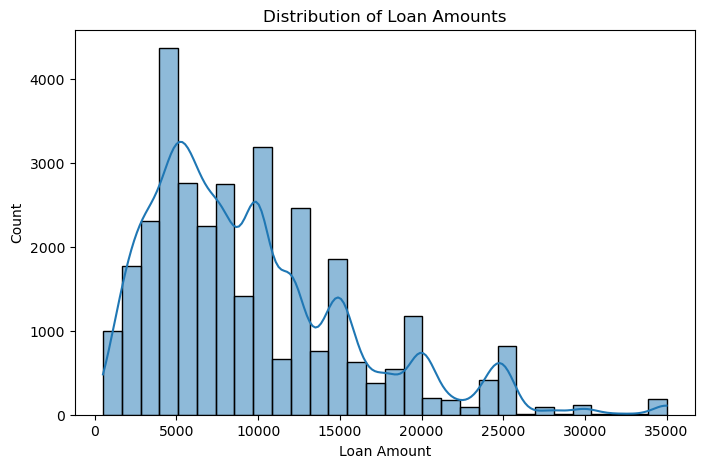

In [30]:
plt.figure(figsize=(8,5)) 
sns.histplot( df['loan_amnt'], bins=30, kde=True ) 
plt.title('Distribution of Loan Amounts') 
plt.xlabel('Loan Amount') 
plt.show()

#### The average loan size across the portfolio is $9,592, but the distribution tells a more useful story than the average alone.

- The distribution is right-skewed with a clear peak around $5,000-6,000 — the single most common loan size in the portfolio, and the tallest bar by a wide margin (over 4,000 loans). Most borrowers are taking out relatively small loans.

- Distinct secondary clusters appear around $10,000, $15,000, $20,000, and $25,000 — the multiple bumps in the KDE curve suggest loan amounts aren't smoothly continuous but cluster around common round-number request sizes, which is typical of how borrowers and lenders think about loan amounts (people ask for $10k or $15k, not $11,347).

- The right skew means the average ($9,592) sits above where most individual loans actually fall. With the bulk of volume concentrated in the $2,500-$10,000 range, the mean is being pulled upward by a longer tail of larger loans extending out to $35,000. For reporting purposes, pairing this average with the median would give a more honest picture of the "typical" loan size — I'd expect the median to sit noticeably below $9,592 given this shape.

## What is the overall default rate?

In [31]:
default_rate = df['loan_status'] .mean() * 100 
print('The Default Rate is',default_rate,'%')

The Default Rate is 21.870468079854362 %


In [32]:
loan_status=df['loan_status'] .value_counts(normalize=True) * 100
loan_status

loan_status
0    78.129532
1    21.870468
Name: proportion, dtype: float64

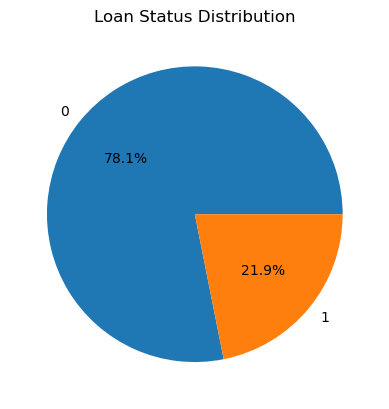

In [33]:
loan_status.plot( kind='pie', autopct='%1.1f%%' ) 
plt.title('Loan Status Distribution') 
plt.ylabel('') 
plt.show()

#### Loan Status Distribution

- 78.1% of loans are non-default (status 0), 21.9% are default (status 1).
- The default rate matches the "21.87%" figure printed just above the chart.
- The pie chart splits into two segments only, labeled "0" and "1" on the chart itself, corresponding to the two loan_status values.
- The blue segment (non-default) is roughly 3.5x larger than the orange segment (default).

## How are borrowers distributed across age groups?

In [34]:
age_dist =df['Age_Group'] .value_counts()
age_dist

Age_Group
18-25    15243
26-35    13711
36-45     2809
46-55      512
55+        134
Name: count, dtype: int64

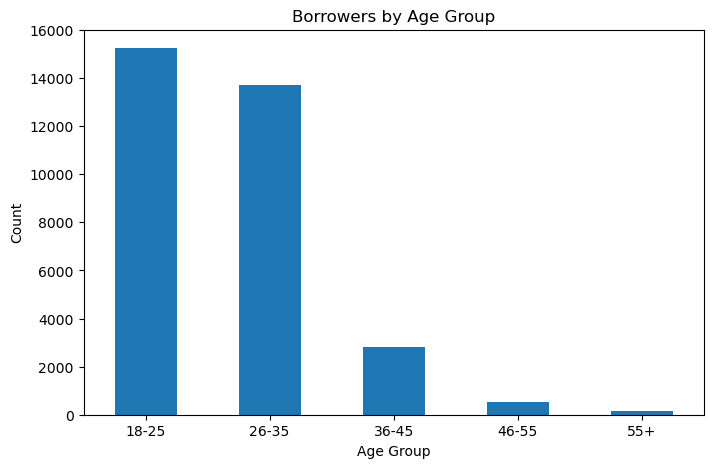

In [35]:
age_dist.plot( kind='bar', figsize=(8,5) )
plt.title('Borrowers by Age Group') 
plt.xlabel('Age Group') 
plt.ylabel('Count') 
plt.xticks(rotation=0)
plt.show()

#### Borrowers by Age Group

- 18-25 is the tallest bar, at roughly 15,300.

- 26-35 is second, at roughly 13,800.

- 36-45 drops sharply to roughly 2,900.

- 46-55 is roughly 600.

- 55+ is the smallest bar, roughly 250.

## How are borrowers distributed across income categories?

In [36]:
income_dist =df['Income_Category'] .value_counts()
income_dist

Income_Category
Medium       8188
Low          8104
Very High    8099
High         8018
Name: count, dtype: int64

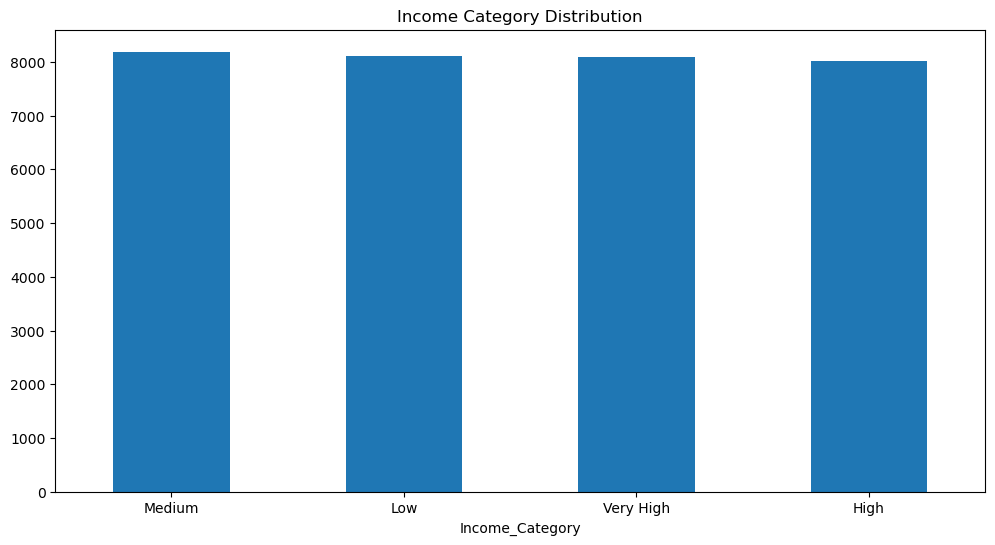

In [37]:
income_dist.plot( kind='bar', figsize=(12,6) ) 
plt.title('Income Category Distribution') 
plt.xticks(rotation=0)
plt.show()

#### Income Category Distribution

- Bars appear in the order: Medium, Low, Very High, High.
Medium is the tallest bar, just above 8,000.

- Low is roughly 8,000.

- Very High is roughly 8,000.

- High is roughly 8,000, slightly lower than the other three.

#### All four bars are close in height, with only small differences between them.

## Which loan intentions are most common?

In [38]:
loan_intents =df['loan_intent'].value_counts() 
loan_intents

loan_intent
EDUCATION            6409
MEDICAL              6042
VENTURE              5679
PERSONAL             5496
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

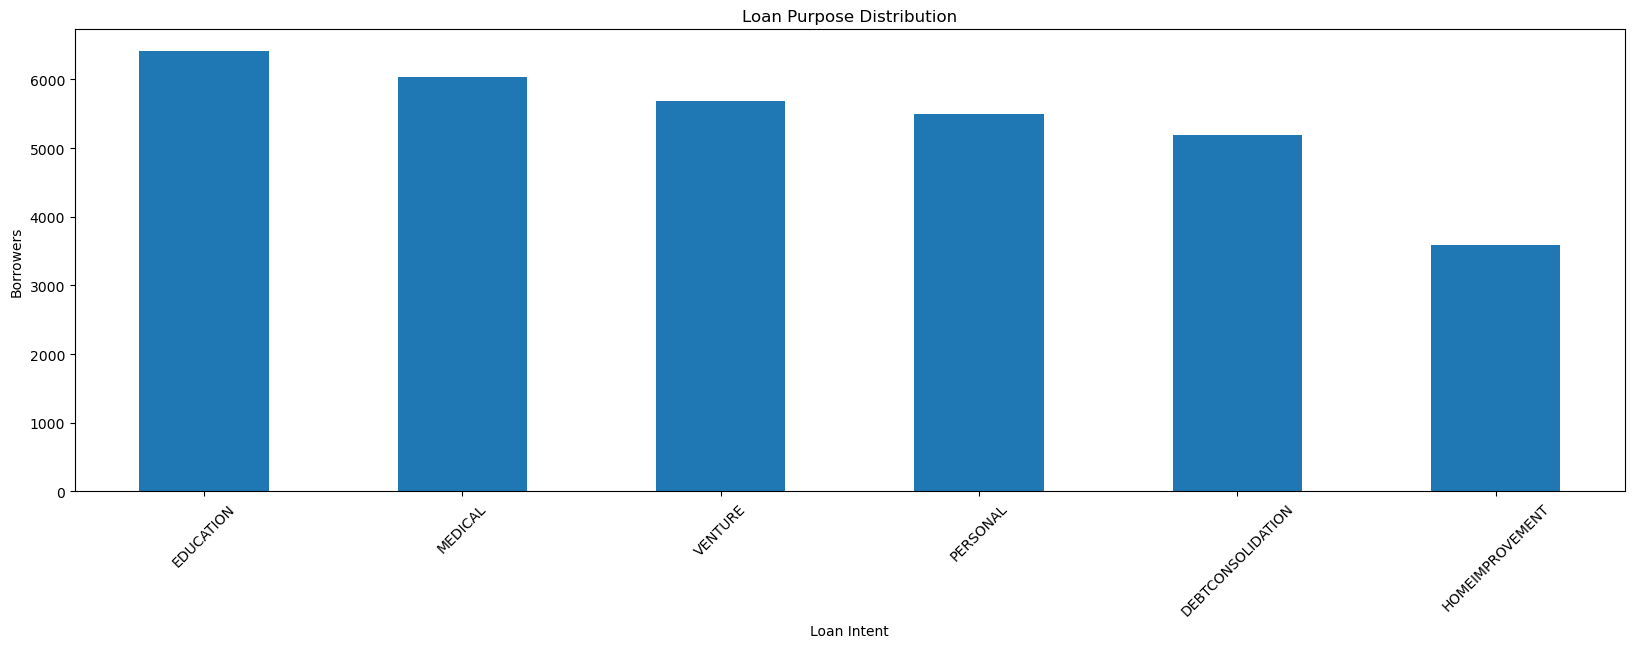

In [39]:
loan_intents.plot( kind='bar', figsize=(20,6) ) 
plt.title('Loan Purpose Distribution') 
plt.xlabel('Loan Intent') 
plt.ylabel('Borrowers') 
plt.xticks(rotation=45)
plt.show()

#### Loan Purpose Distribution — Business Insight

- Education is the leading reason borrowers take out loans, ahead of all other purposes.

- Medical and Venture are the next most common purposes, both close behind Education.

- Personal and Debt Consolidation represent a mid-tier share of loan purposes.

- Home Improvement is the least common loan purpose, notably behind the other five.

- Borrowing demand is spread across a mix of purposes rather than concentrated in a single dominant category.

## What is the distribution of home ownership status?


In [40]:
home_dist = df['person_home_ownership'] .value_counts()
home_dist

person_home_ownership
RENT        16374
MORTGAGE    13366
OWN          2563
OTHER         106
Name: count, dtype: int64

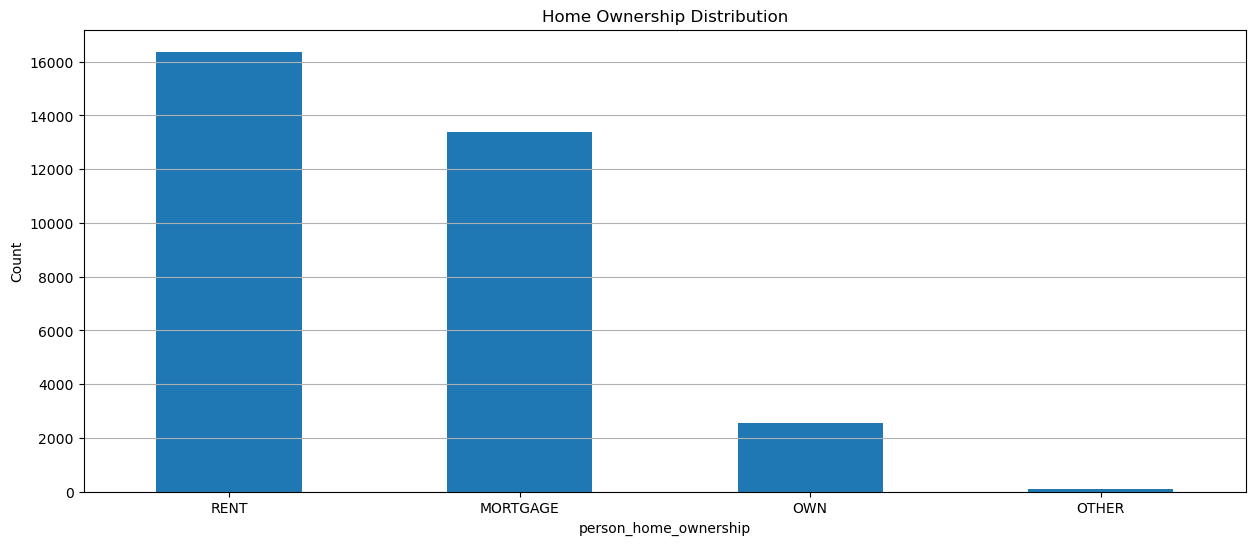

In [41]:
home_dist.plot( kind='bar', figsize=(15,6) ) 
plt.title('Home Ownership Distribution') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.ylabel('Count')
plt.show()

#### Home Ownership Distribution — Business Insight

- Rent is the most common home ownership status among borrowers, at roughly 16,400.
Mortgage is the second most common, at roughly 13,400.

- Own is far behind the top two, at roughly 2,600.

- Other is a negligible category, close to 0.

- The large majority of borrowers rent or have a mortgage, rather than owning their home outright.

## How are loans distributed across loan grades?

In [42]:
grade_dist = df['loan_grade'] .value_counts()
grade_dist

loan_grade
A    10702
B    10384
C     6436
D     3619
E      963
F      241
G       64
Name: count, dtype: int64

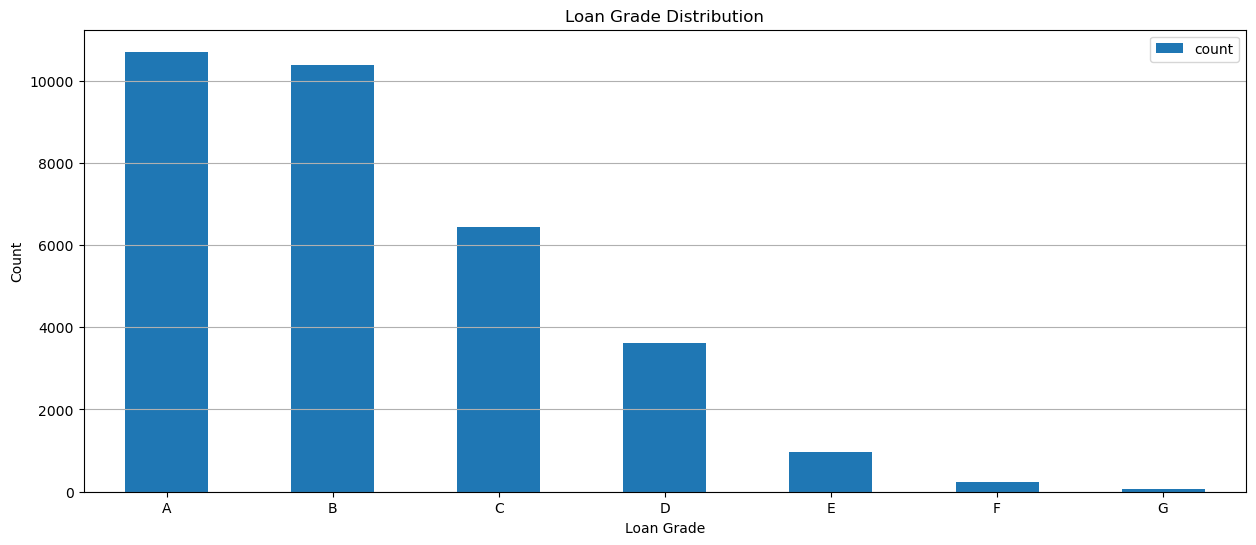

In [43]:
grade_dist.plot(kind='bar',figsize=(15,6))
plt.title('Loan Grade Distribution')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend()
plt.show()

- Loan volume is heavily concentrated in Grades A and B, which together account for over half the portfolio.

- Volume declines steadily from A to G, with each successive grade holding a smaller share than the last.

- The lowest-quality grades (E, F, G) represent a very small fraction of total lending activity.

- This letter-grade view confirms the earlier numeric-grade pattern: underwriting is skewed toward safer, higher-grade loans.

## What is the distribution of Risk Segments?

In [44]:
risk_dist = df['Risk_Segment'] .value_counts()
risk_dist

Risk_Segment
Low Risk         8103
Medium Risk      8102
High Risk        8102
Critical Risk    8102
Name: count, dtype: int64

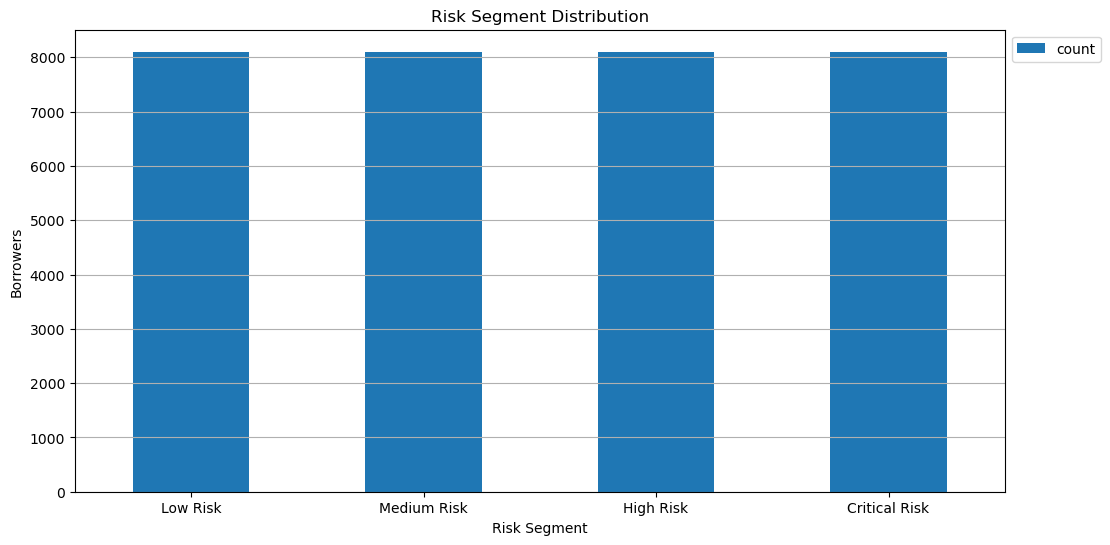

In [45]:
risk_dist.plot( kind='bar', figsize=(12,6) ) 
plt.title('Risk Segment Distribution') 
plt.xlabel('Risk Segment') 
plt.ylabel('Borrowers') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

- Borrower counts are evenly split across all four risk segments, confirming this is a quartile-based split rather than a distribution shaped by actual risk levels.

- "Critical Risk" holding the same borrower count as "Low Risk" signals this label reflects relative ranking within the portfolio, not an absolute risk threshold.

- Segment labels are correctly ordered (Low to Critical), making this version stakeholder-ready.

- Equal segment sizes mean this chart alone can't tell whether the risk score is actually predictive of outcomes like default.

## Which Exposure Categories contain the largest number of borrowers?

In [46]:
exposure_dist =df['Exposure_Category'] .value_counts()
exposure_dist

Exposure_Category
Low         8103
Medium      8102
High        8102
Critical    8102
Name: count, dtype: int64

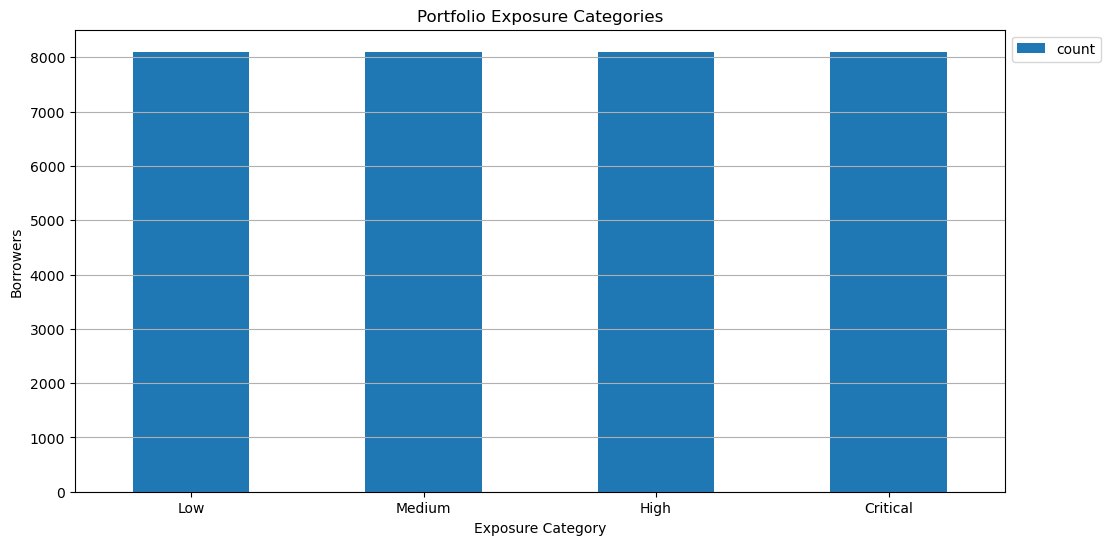

In [47]:
exposure_dist.plot( kind='bar', figsize=(12,6) ) 
plt.title('Portfolio Exposure Categories') 
plt.xlabel('Exposure Category') 
plt.ylabel('Borrowers') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

- Borrower counts are evenly split across Low, Medium, High, and Critical exposure categories, confirming this is a quartile-based split rather than a true risk-driven distribution.

- No exposure tier dominates the portfolio in borrower count, so headline dollar exposure concentration isn't visible from this view alone.

- The "Critical" tier holding exactly the same borrower count as "Low" suggests this label reflects relative ranking within the portfolio, not an absolute exposure threshold.

- Category labels are correctly ordered (Low to Critical), unlike the earlier Risk Segment chart, making this version more stakeholder-ready as is.

## Which age group has the highest default rate?

In [48]:
age_default = (df.groupby('Age_Group', observed=False)['loan_status'].mean() * 100).sort_values(ascending=False)
age_default

Age_Group
55+      23.880597
18-25    23.131929
46-55    21.875000
26-35    20.691416
36-45    20.683517
Name: loan_status, dtype: float64

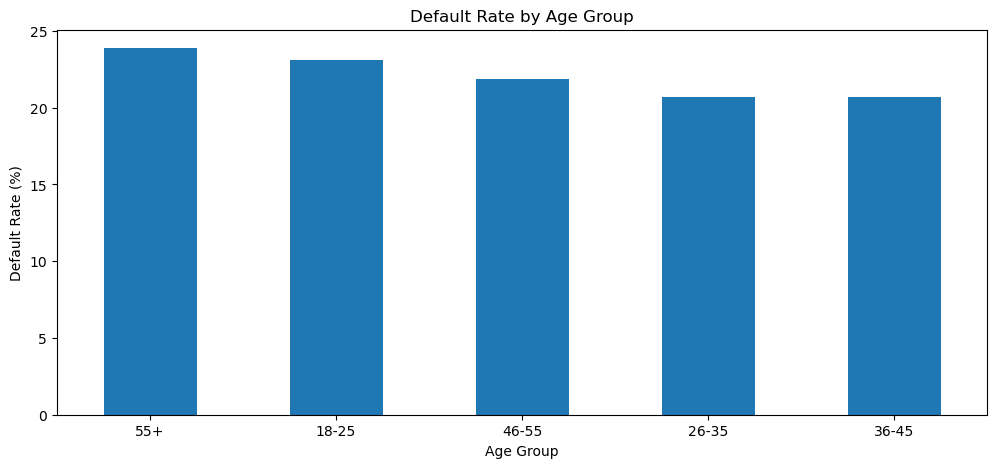

In [49]:
age_default.plot( kind='bar', figsize=(12,5) )
plt.title('Default Rate by Age Group') 
plt.ylabel('Default Rate (%)')
plt.xlabel('Age Group') 
plt.xticks(rotation=0)
plt.show()

- Default risk is highest at both ends of the age spectrum, with 55+ and 18-25 leading despite being very different life stages.

- Middle-aged borrowers (26-45) show the most stable, lowest default behavior, making them the safest segment by age alone.

- The gap between the highest and lowest default rate is relatively narrow, so age alone isn't a strong standalone risk differentiator.

- The 55+ group defaulting most despite typically having more credit history suggests other factors (income stability, loan purpose) may be driving this beyond age itself.

## Which income category has the highest default rate?

In [50]:
income_default = (df.groupby('Income_Category', observed=False)['loan_status'].mean() * 100).sort_values(ascending=False)
income_default

Income_Category
Low          39.745805
Medium       21.409380
High         17.136443
Very High     9.136930
Name: loan_status, dtype: float64

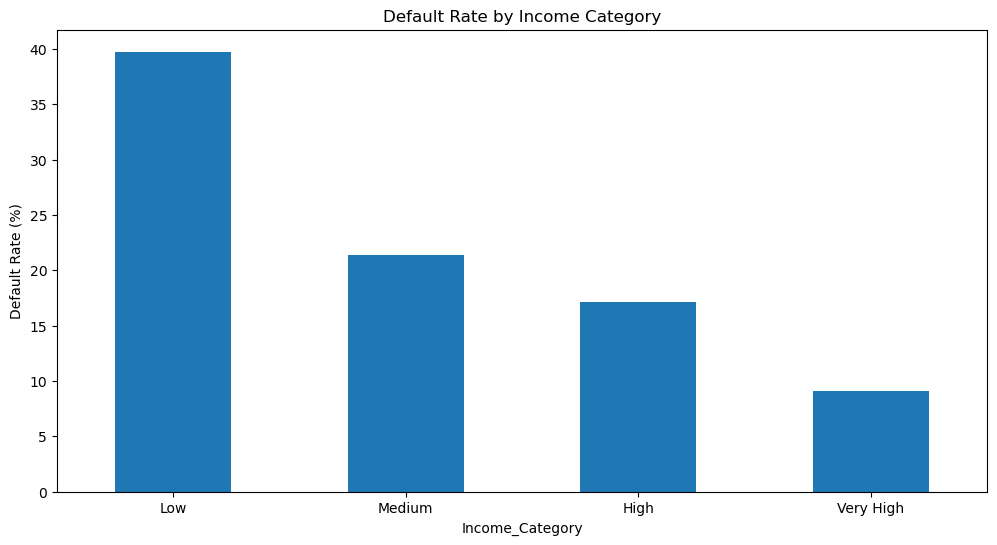

In [51]:
income_default.plot( kind='bar', figsize=(12,6) ) 
plt.title('Default Rate by Income Category') 
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

- Default rate falls sharply and consistently as income rises, making income one of the strongest single predictors of default in this dataset.

- Low-income borrowers default at nearly 40%, more than four times the rate of Very High income borrowers.

- The drop from Low to Medium income alone cuts the default rate almost in half, showing the steepest risk reduction happens at the bottom of the income scale.

- This pattern is far more pronounced than the age-based default differences seen earlier, suggesting income is a much stronger risk driver than age group alone.

## Which home ownership category has the highest default rate?

In [52]:
home_default = (df.groupby('person_home_ownership', observed=False)['loan_status'].mean() * 100).sort_values(ascending=False) 
home_default

person_home_ownership
RENT        31.611091
OTHER       31.132075
MORTGAGE    12.621577
OWN          7.491221
Name: loan_status, dtype: float64

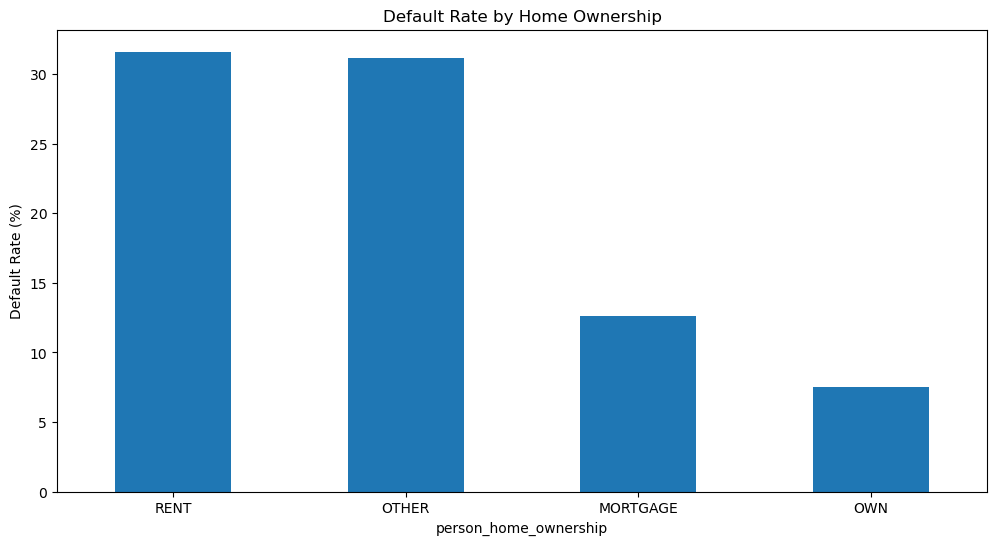

In [53]:
home_default.plot( kind='bar', figsize=(12,6) )
plt.title('Default Rate by Home Ownership') 
plt.ylabel('Default Rate (%)') 
plt.xticks(rotation=0)
plt.show()

- Renters and the "Other" category default at roughly 4x the rate of homeowners, making home ownership status a strong risk signal.

- Borrowers who own their home outright have the lowest default rate by a wide margin, despite being one of the smallest groups by volume.

- Mortgage holders sit in a clear middle tier, defaulting far less than renters but still notably more than outright owners.

- The "Other" category defaulting nearly as high as Rent is notable given it represents a negligible share of borrowers, so this rate should be treated cautiously given likely small sample size.

## Which employment stability group has the highest default rate?

In [54]:
employment_default =(df.groupby('Employment_Stability',observed=False)['loan_status'] .mean() * 100).sort_values(ascending=False) 
employment_default

Employment_Stability
Low          27.122249
Medium       21.075524
High         18.099019
Very High    16.226415
Name: loan_status, dtype: float64

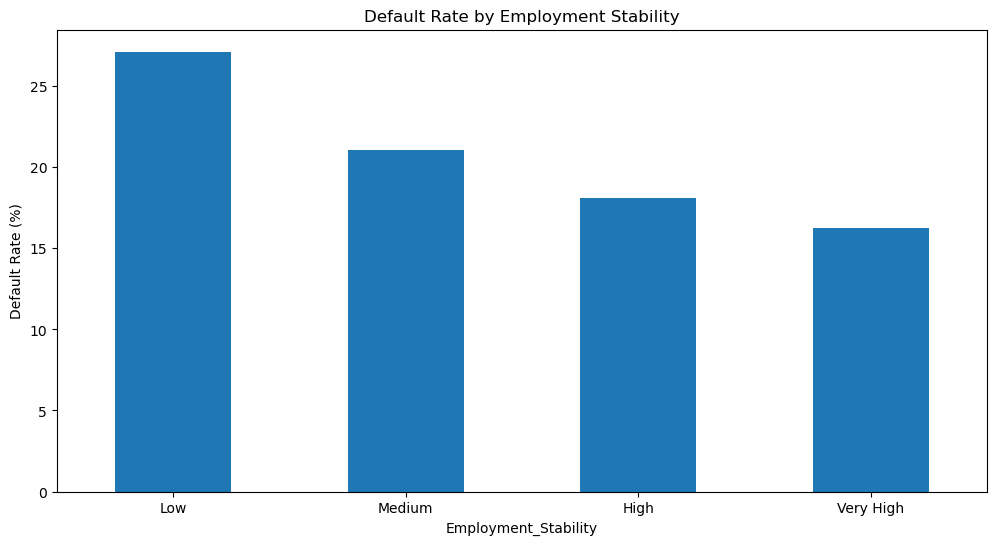

In [55]:
employment_default.plot( kind='bar', figsize=(12,6) )
plt.title('Default Rate by Employment Stability')
plt.ylabel('Default Rate (%)') 
plt.xticks(rotation=0)
plt.show()

- Default rate declines steadily as employment stability increases, confirming tenure length is a meaningful risk factor.

- Borrowers with the least stable employment default at nearly double the rate of the most stable group.

- The drop between Low and Medium stability is the steepest jump in the chart, suggesting even a small amount of tenure meaningfully reduces risk.

- The gap between High and Very High stability is comparatively narrow, indicating diminishing risk reduction once a borrower already has a solid employment history.

## What is the average income by loan grade?

In [56]:
grade_income =df.groupby('loan_grade')['person_income'] .mean() 
grade_income

loan_grade
A    66594.119230
B    66317.057107
C    64012.983064
D    63704.396518
E    70856.360332
F    77008.730290
G    76773.296875
Name: person_income, dtype: float64

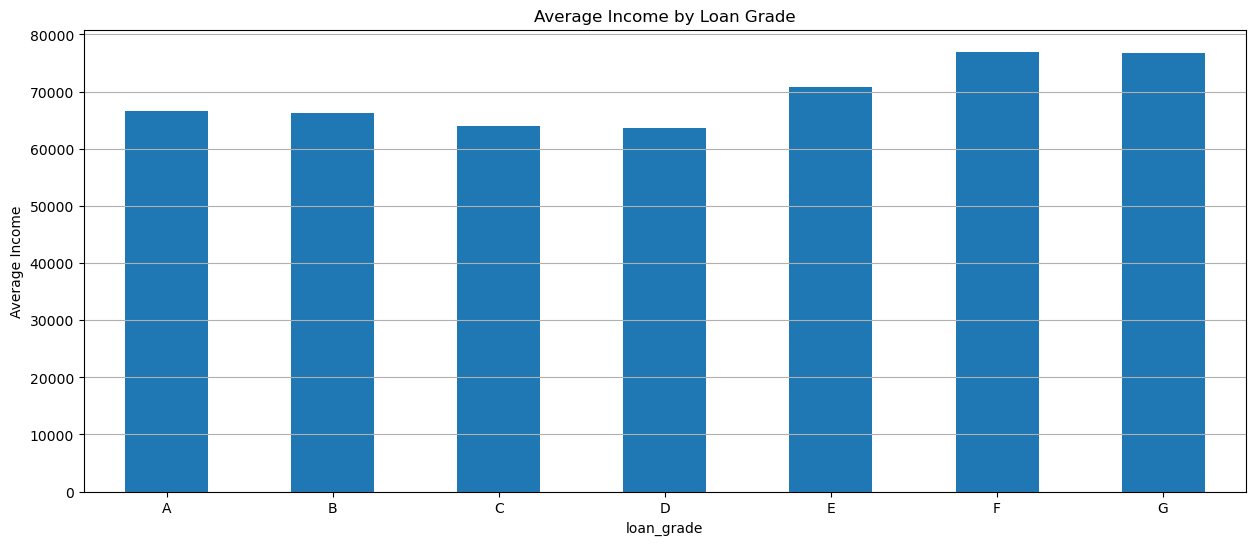

In [57]:
grade_income.plot( kind='bar', figsize=(15,6) ) 
plt.title('Average Income by Loan Grade') 
plt.ylabel('Average Income') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Average income doesn't decline as loan grade worsens — in fact, the lowest grades (E, F, G) have the highest average income of any group.

- This contradicts the assumption that lower loan grades represent lower-income, higher-risk borrowers by income alone.

- Grades A through D are relatively flat and close together in average income, showing little income differentiation among the "safer" grade tiers.

- Since lower grades still show higher income, loan grade appears to be driven more by factors like debt burden or credit history than by income directly.

## Which loan intentions are associated with the highest average loan amounts?

In [58]:
intent_loan =df.groupby('loan_intent')['loan_amnt'] .mean() .sort_values(ascending=False)
intent_loan

loan_intent
HOMEIMPROVEMENT      10362.124374
DEBTCONSOLIDATION     9605.270765
VENTURE               9579.415390
PERSONAL              9575.891557
EDUCATION             9478.889062
MEDICAL               9271.578120
Name: loan_amnt, dtype: float64

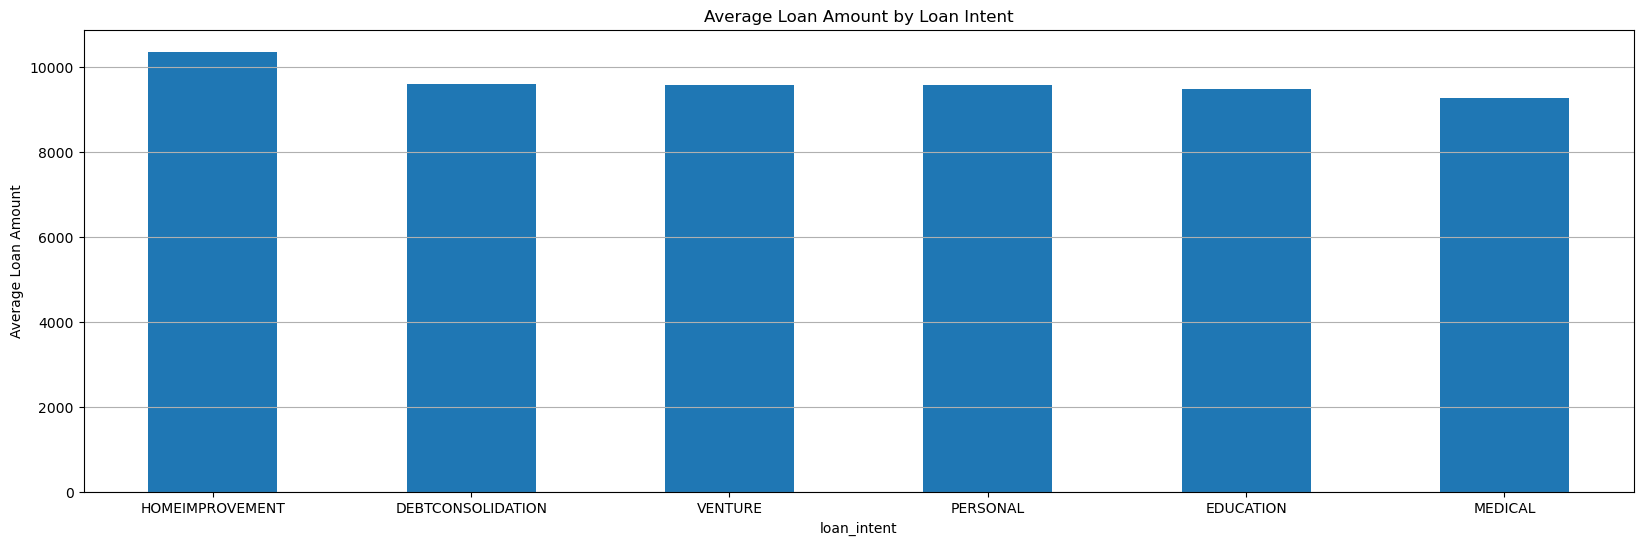

In [59]:
intent_loan.plot( kind='bar', figsize=(20,6) ) 
plt.title('Average Loan Amount by Loan Intent') 
plt.ylabel('Average Loan Amount') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Average loan amount is remarkably consistent across all loan purposes, with no category standing out as dramatically larger or smaller

- Home Improvement carries the highest average loan size, despite being the least common loan purpose by borrower count.

- Medical has the lowest average loan amount, even though medical expenses can often be unpredictable or urgent.

- The narrow spread across categories suggests loan intent alone doesn't strongly differentiate borrowing amount, unlike the stronger differentiation seen in default rate by income or employment stability.

## Which age groups receive the largest loans?

In [60]:
age_loan = df.groupby('Age_Group',observed=False)['loan_amnt'] .mean() .sort_values(ascending=False)
age_loan

Age_Group
55+      10356.156716
36-45     9985.101460
46-55     9948.535156
26-35     9917.564364
18-25     9209.056616
Name: loan_amnt, dtype: float64

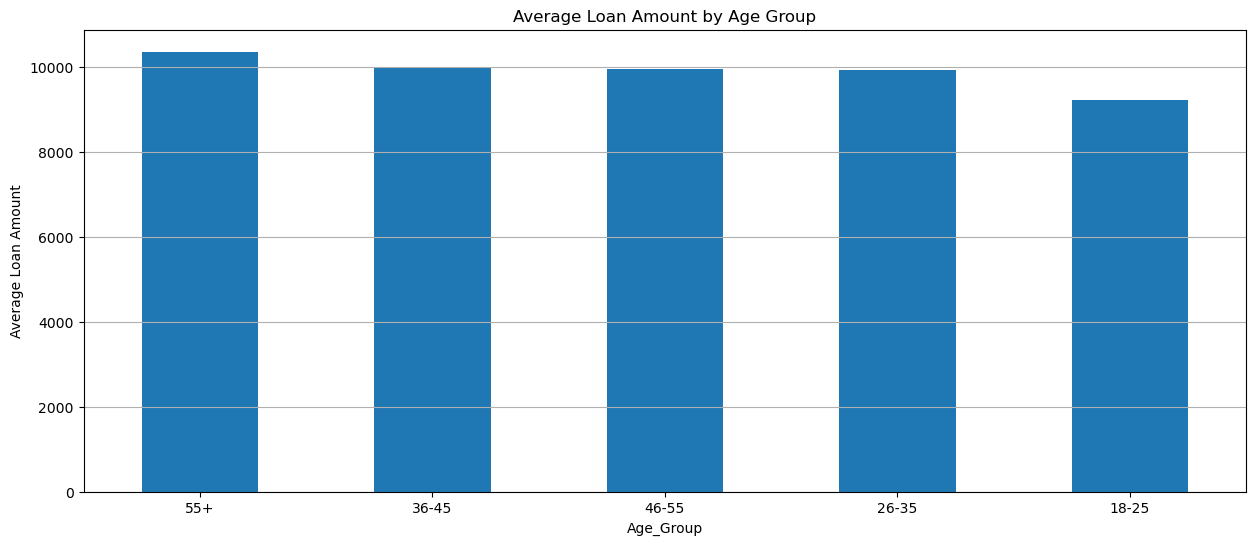

In [61]:
age_loan.plot( kind='bar', figsize=(15,6) ) 
plt.title('Average Loan Amount by Age Group') 
plt.ylabel('Average Loan Amount') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Average loan amount is fairly stable across age groups, with only a modest decline for the youngest borrowers.

- 18-25 has the lowest average loan amount despite defaulting at one of the highest rates seen earlier, suggesting smaller loan sizes aren't offsetting their elevated risk.

- 55+ has both the highest average loan amount and the highest default rate, a combination that raises the stakes on that segment from a dollar-exposure standpoint, not just a headcount standpoint.

- Middle age groups (26-45) cluster tightly together in loan amount, mirroring the tight clustering seen earlier in their default rates.

## How does Financial Health Score vary across income categories

In [62]:
income_health =  df.groupby('Income_Category',observed=False) ['Financial_Health_Score'] .mean() .sort_values(ascending=False) 
income_health

Income_Category
Very High    0.102150
High         0.079919
Medium       0.070192
Low          0.056913
Name: Financial_Health_Score, dtype: float64

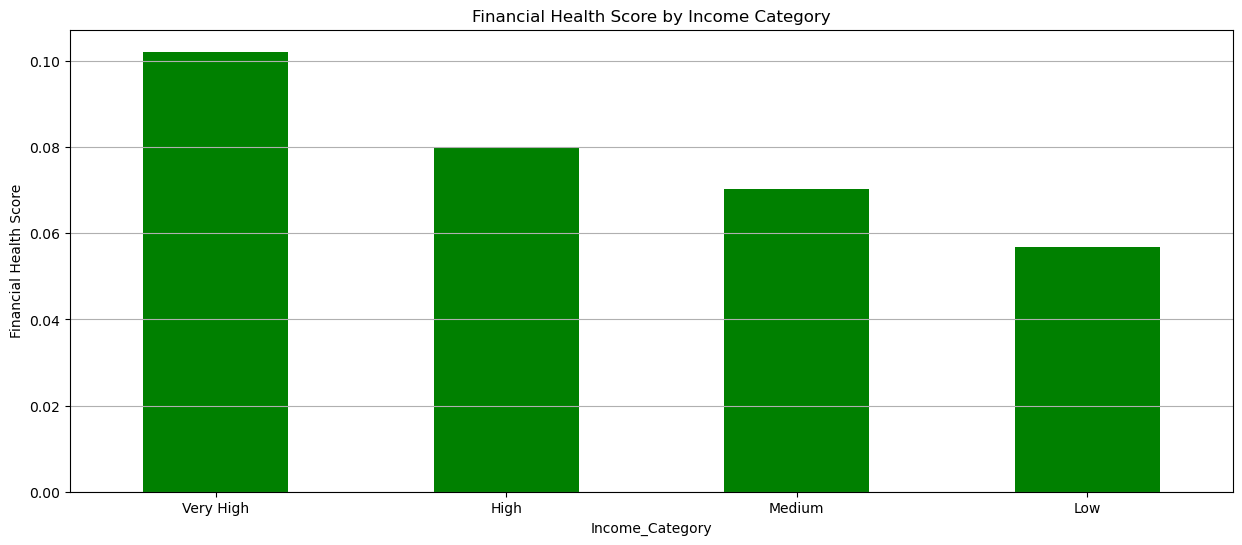

In [63]:
income_health.plot( kind='bar', figsize=(15,6),color='green') 
plt.title('Financial Health Score by Income Category')
plt.ylabel('Financial Health Score') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Financial health score rises consistently with income tier, reinforcing income's role as a strong indicator of overall borrower stability.

- The gap between Very High and Low income groups is nearly 2x, a clear and steady gradient rather than a sharp cutoff at any one tier.

- This pattern lines up directly with the earlier default rate findings, where Low income also had by far the highest default rate — reinforcing income as a consistent thread across multiple risk indicators.

- The steady step-down between each tier suggests financial health is being driven proportionally by income rather than concentrated at just the extremes.

## Which borrowers have the highest Debt Burden Score?

#### Highest Debt Burden Borrowers

Sorting the full dataset by `Debt_Burden_Score` in descending order to identify the individual borrowers carrying the largest loan relative to their income. Financial_Health_Score and income tier already showed income as a strong driver of default risk, but that was at the group level — this pulls out the specific borrowers, not just categories, to see whether high debt burden concentrates in a particular profile (young age, low income, or both) or shows up across a wider mix.

Pulling `person_age`, `person_income`, and `loan_amnt` alongside the score itself, since the ratio alone doesn't show what's actually driving it — a high score from a small loan against very low income is a different risk story than a high score from a large loan against moderate income.

In [64]:
high_debt_burden = ( df.sort_values( by='Debt_Burden_Score', ascending=False ) [ [ 'person_age', 'person_income', 'loan_amnt', 'Debt_Burden_Score' ] ] .head(10) )
high_debt_burden

,person_age,person_income,loan_amnt,Debt_Burden_Score
640,22,20000,16600,0.830000
23727,32,12000,9325,0.777083
577,26,26000,20050,0.771154
571,21,19500,15000,0.769231
18203,30,32004,24250,0.757718
460,24,18000,13000,0.722222
27878,33,10080,7200,0.714286
10007,21,13000,9250,0.711538
2452,25,32004,22750,0.710849
15044,25,25000,17500,0.700000


- Every borrower in the top 10 debt burden list is under 33 years old, making young age a consistent thread across the highest-burden cases.

- Income levels are modest across the board (10,000-32,000), so high debt burden here is not coming from large loans on high income — it's from any meaningful loan size stacked against low income.

- Debt burden scores of 0.70-0.83 mean these borrowers are committing 70-83% of their income to a single loan, an extreme repayment strain regardless of loan size.

- Loan amounts vary widely (7,200 to 24,250), showing the high burden isn't driven by loan size alone — it's the income denominator pulling the ratio up even for moderate loans.

## Which borrower profiles generate the strongest Financial Health Scores?

In [65]:
top_profiles = df.groupby(['Age_Group', 'Income_Category'], observed=False)['Financial_Health_Score'].mean().sort_values(ascending=False)
top_profiles

Age_Group  Income_Category
55+        Very High          0.263528
           High               0.222459
           Medium             0.213886
46-55      Very High          0.190417
55+        Low                0.184826
36-45      Very High          0.173261
46-55      High               0.160409
           Medium             0.158549
           Low                0.152595
36-45      High               0.148399
           Medium             0.135529
           Low                0.122138
26-35      Very High          0.108605
           High               0.090199
           Medium             0.080537
           Low                0.068209
18-25      Very High          0.067770
           High               0.054569
           Medium             0.047223
           Low                0.036356
Name: Financial_Health_Score, dtype: float64

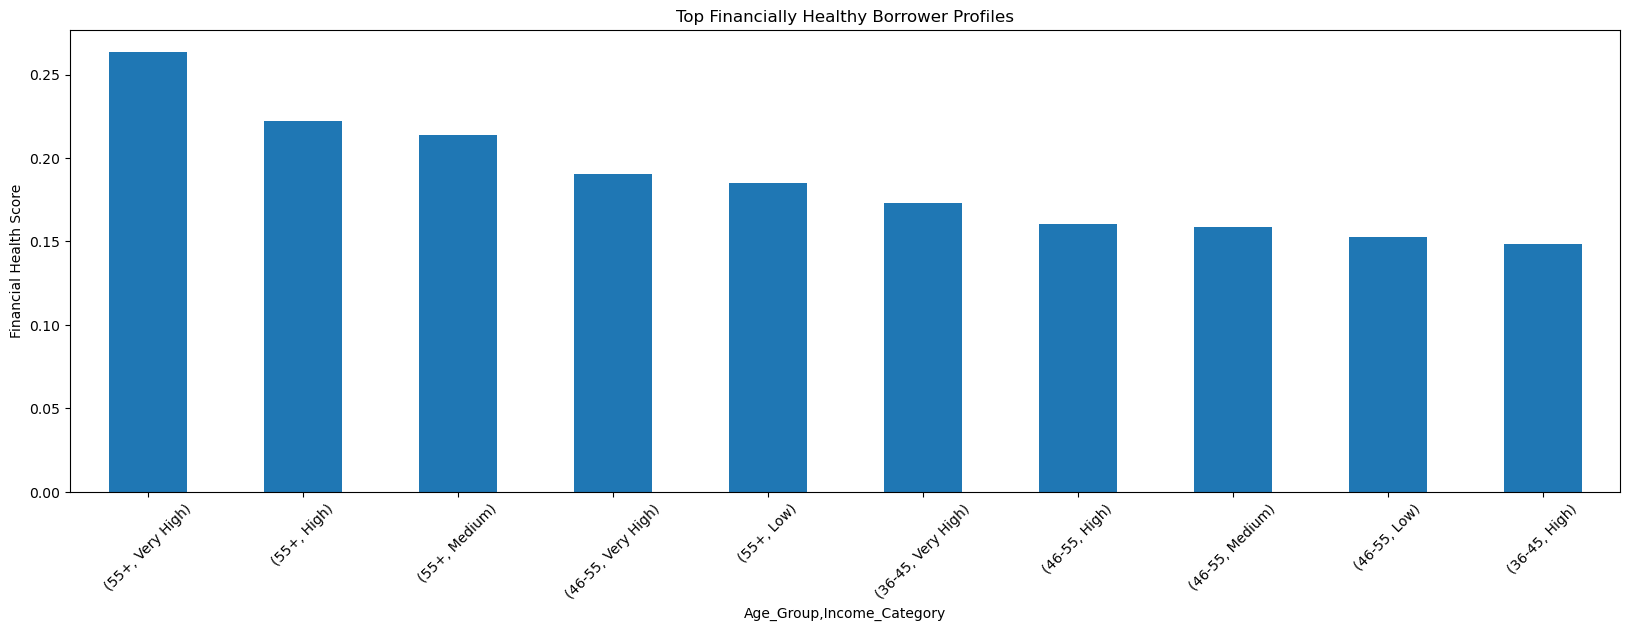

In [66]:
top_profiles.head(10).plot( kind='bar', figsize=(20,6) ) 
plt.title( 'Top Financially Healthy Borrower Profiles' ) 
plt.ylabel('Financial Health Score') 
plt.xticks(rotation=45)
plt.show()

- The (55+, Very High income) profile has the strongest financial health score by a clear margin, ahead of every other combination.

- Age dominates this ranking more than income tier alone — 55+ occupies 4 of the top 5 spots, appearing even at Low income, ahead of several younger high-income groups.

- Even (55+, Low income) outranks (46-55, Low income) and comes close to (36-45, Very High income), showing age carries independent weight beyond income level.

- This directly contrasts the earlier default rate finding, where 55+ also had the highest default rate — meaning this age group scores well on financial health inputs (income, employment length, credit history) while still defaulting most often, a disconnect worth investigating further.

## Which loan grades have the highest default rates?

In [67]:
grade_default =(df.groupby('loan_grade')['loan_status'] .mean()*100) .sort_values(ascending=False)
grade_default

loan_grade
G    98.437500
F    70.539419
E    64.485981
D    59.049461
C    20.758235
B    16.323190
A     9.960755
Name: loan_status, dtype: float64

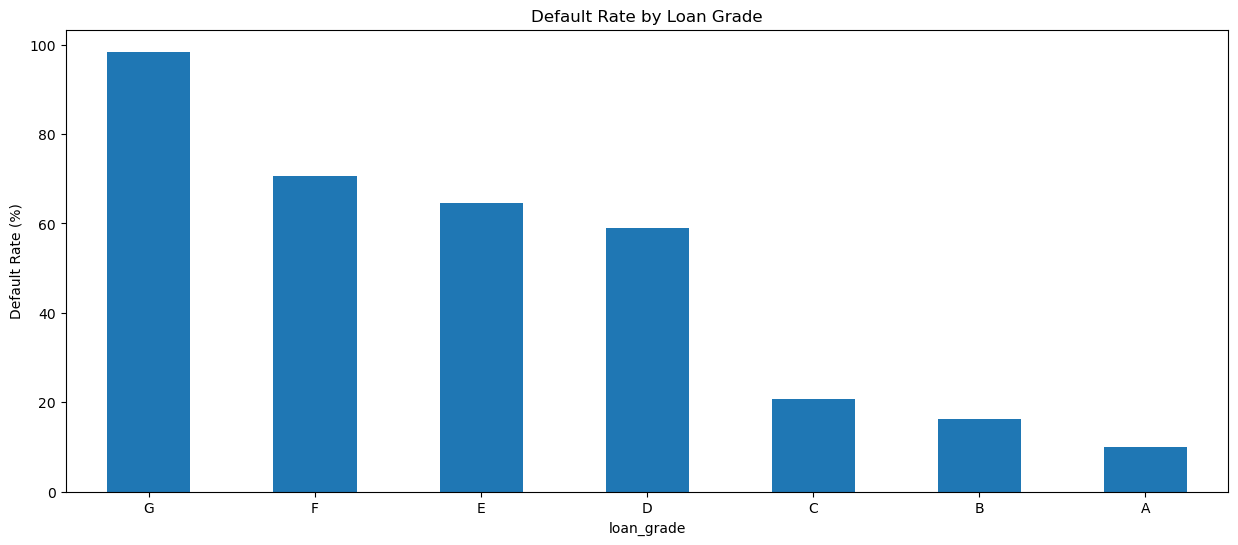

In [68]:
grade_default.plot( kind='bar', figsize=(15,6) ) 
plt.title('Default Rate by Loan Grade') 
plt.ylabel('Default Rate (%)') 
plt.xticks(rotation=0)
plt.show()

- Default rate rises sharply and almost monotonically from Grade A through Grade G, confirming loan grade is a strong, well-ordered risk signal.

- Grade G defaults nearly 10x more often than Grade A, the widest gap seen across any single-variable breakdown so far.

- The jump from D to E to F to G is much steeper than the jump from A to B to C, meaning risk accelerates disproportionately at the lower grade tiers rather than increasing at a constant rate.

- This contradicts the earlier income-by-grade finding, where lower grades actually had higher average income — meaning income alone doesn't explain why these grades default so much more, so the grading system is likely weighting other factors (like debt burden or credit history) more heavily than income.

## Which loan purposes have the highest default rates?

In [69]:
intent_default = ( df.groupby('loan_intent')['loan_status'] .mean()*100) .sort_values(ascending=False)
intent_default

loan_intent
DEBTCONSOLIDATION    28.676045
MEDICAL              26.762661
HOMEIMPROVEMENT      26.154702
PERSONAL             19.887191
EDUCATION            17.256982
VENTURE              14.861771
Name: loan_status, dtype: float64

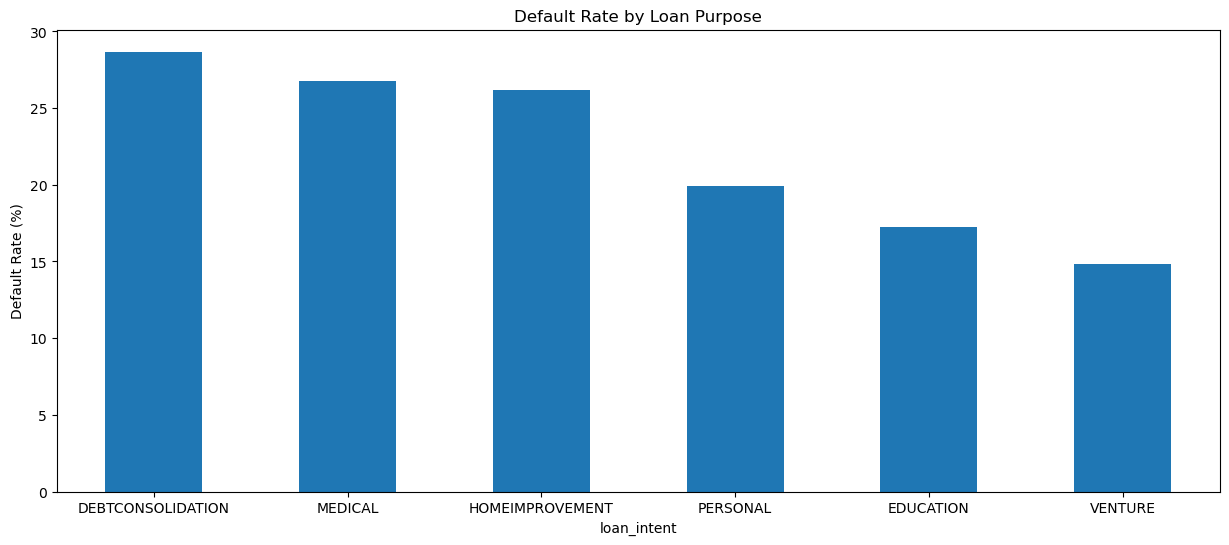

In [70]:
intent_default.plot( kind='bar', figsize=(15,6) ) 
plt.title('Default Rate by Loan Purpose') 
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

- Debt Consolidation, Medical, and Home Improvement form a clear high-default cluster, all close together near 26-29%.
    
- Venture has the lowest default rate despite earlier showing one of the largest average loan amounts, suggesting purpose-driven risk doesn't align with loan size.

- Education defaults notably less often than Medical or Debt Consolidation, even though it was the most common loan purpose by volume.

- Debt Consolidation defaulting highest is notable given its purpose is literally to manage existing debt, suggesting these borrowers may already be in financial distress before taking the loan.

## How does default rate change across Risk Segments?

In [71]:
risk_default = (df.groupby('Risk_Segment',observed=False)['loan_status'] .mean() *100) 
risk_default

Risk_Segment
Low Risk          4.479822
Medium Risk       9.972846
High Risk        19.377931
Critical Risk    53.653419
Name: loan_status, dtype: float64

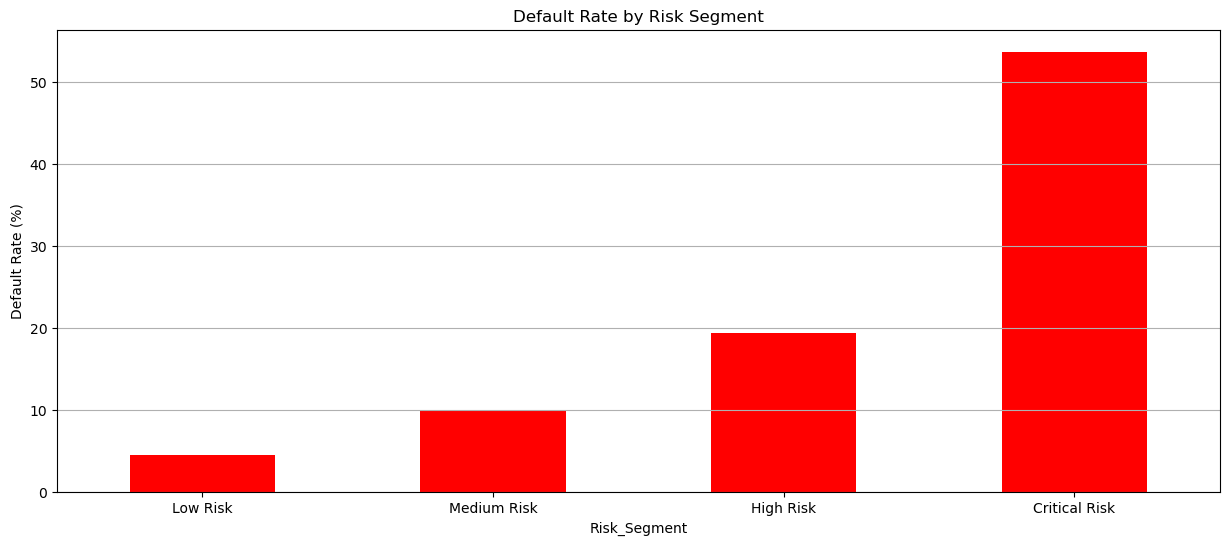

In [72]:
risk_default.plot( kind='bar', figsize=(15,6),color='Red' )
plt.title('Default Rate by Risk Segment')
plt.ylabel('Default Rate (%)') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Default rate climbs sharply and consistently from Low Risk to Critical Risk, confirming the constructed Risk_Score is genuinely predictive of actual default outcomes.

- Critical Risk defaults over 10x more often than Low Risk, despite both segments holding equal borrower counts by design.

- This validates the earlier concern about equal-sized quartile segments — even though "Critical" was just the top 25% by construction, that top quartile does correspond to meaningfully higher real-world default behavior.

- The jump from High Risk to Critical Risk is the steepest single step in the chart, nearly tripling the default rate, showing risk concentrates disproportionately at the very top of the score distribution rather than increasing at a steady pace.

## Does loan amount influence default probability?

In [73]:
df[['loan_status', 'loan_amnt']].corr()

,loan_status,loan_amnt
loan_status,1.000000,0.105601
loan_amnt,0.105601,1.000000


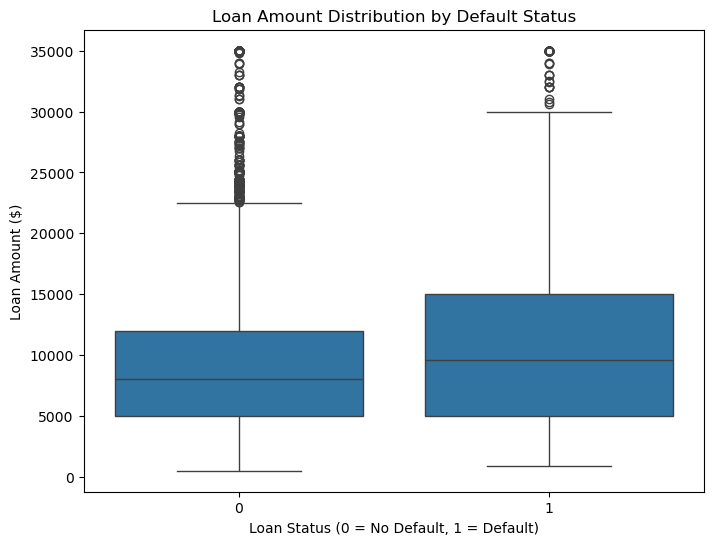

In [74]:
plt.figure(figsize=(8,6))
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount Distribution by Default Status')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Loan Amount ($)')
plt.show()

- Defaulters have a noticeably higher median loan amount (~ 9,700) than non-defaulters (~ 8,000), consistent with the weak positive correlation found earlier.

- The upper quartile boundary is higher for defaulters (~ 15,000) than non-defaulters (~ 12,000), meaning larger loans within this group cluster higher overall, not just at the extremes.

- Non-defaulters show a much longer tail of high-value outliers (up to 35,000, densely packed above 22,500), while defaulters have fewer, more scattered outliers.

- The two boxes overlap substantially, meaning loan amount alone doesn't cleanly separate defaulters from non-defaulters — reinforcing that this is a weak, not a strong, individual predictor.

## How does interest rate affect default behavior?

In [75]:
int_rate_default = (df.groupby('Interest_Risk', observed=True)['loan_status'].mean() * 100).sort_values(ascending=False)
int_rate_default

Interest_Risk
Very High    42.740640
High         18.596656
Medium       17.132941
Low           9.632537
Name: loan_status, dtype: float64

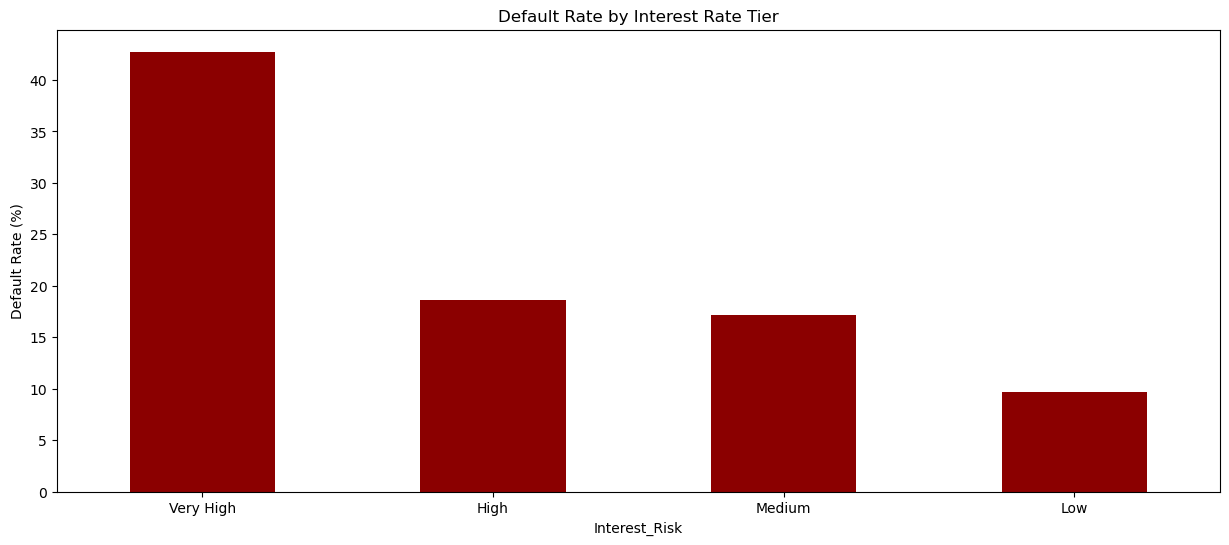

In [76]:
int_rate_default.plot(kind='bar', figsize=(15,6), color='darkred')
plt.title('Default Rate by Interest Rate Tier')
plt.xlabel('Interest_Risk')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

- Very High interest rate tier defaults over 4x more often than Low, the sharpest gap seen in any single-variable breakdown in this project so far.

- The jump from Medium/High (~ 17-19%) to Very High (~ 43%) is dramatic, while High and Medium are nearly identical to each other.

- The near-flat relationship between Low, Medium, and High suggests most of the real risk differentiation is concentrated only in that top interest rate tier, not spread evenly across all four.

- This pattern is far stronger than loan amount's relationship with default, suggesting interest rate is a much more powerful individual predictor of default behavior.

## How does Debt Burden Score affect default rates?

In [77]:
df['Debt_Burden_Group'] = pd.qcut( df['Debt_Burden_Score'], q=4, labels=[ 'Low', 'Medium', 'High', 'Critical' ] )
df['Debt_Burden_Group']

1          Medium
2        Critical
3        Critical
4        Critical
5        Critical
           ...   
32576      Medium
32577      Medium
32578    Critical
32579      Medium
32580        High
Name: Debt_Burden_Group, Length: 32409, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Critical']

In [78]:
debt_default = ( df.groupby('Debt_Burden_Group',observed=False)['loan_status'] .mean() *100 ) 
debt_default

Debt_Burden_Group
Low         11.045292
Medium      13.014036
High        17.698678
Critical    45.767948
Name: loan_status, dtype: float64

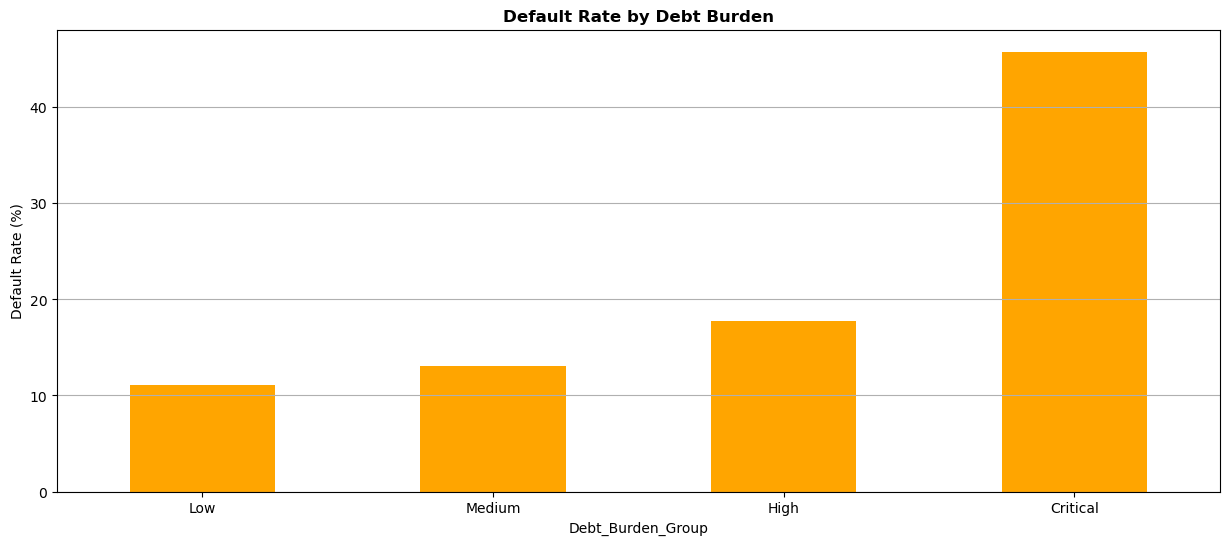

In [79]:
debt_default.plot( kind='bar', figsize=(15,6),color='orange' ) 
plt.title('Default Rate by Debt Burden', fontweight='bold')
plt.ylabel('Default Rate (%)') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Critical debt burden defaults at over 4x the rate of Low, one of the widest gaps seen across any risk factor in this project.

- The rise from Low to Medium to High is fairly gradual, but the jump from High to Critical nearly triples the default rate, showing risk accelerates sharply only at the extreme end.

- This mirrors the same "sharp jump at the top tier only" pattern seen in the interest rate breakdown, suggesting both variables identify a similar small group of extreme-risk borrowers.

- Debt burden shows a cleaner, more consistent upward trend across all four tiers than loan grade did, with no reversals or flat segments between groups.

## Are previous defaulters more likely to default again?

In [80]:
previous_default = ( df.groupby('cb_person_default_on_file') ['loan_status'] .mean() *100 )
previous_default

cb_person_default_on_file
N    18.437031
Y    37.860010
Name: loan_status, dtype: float64

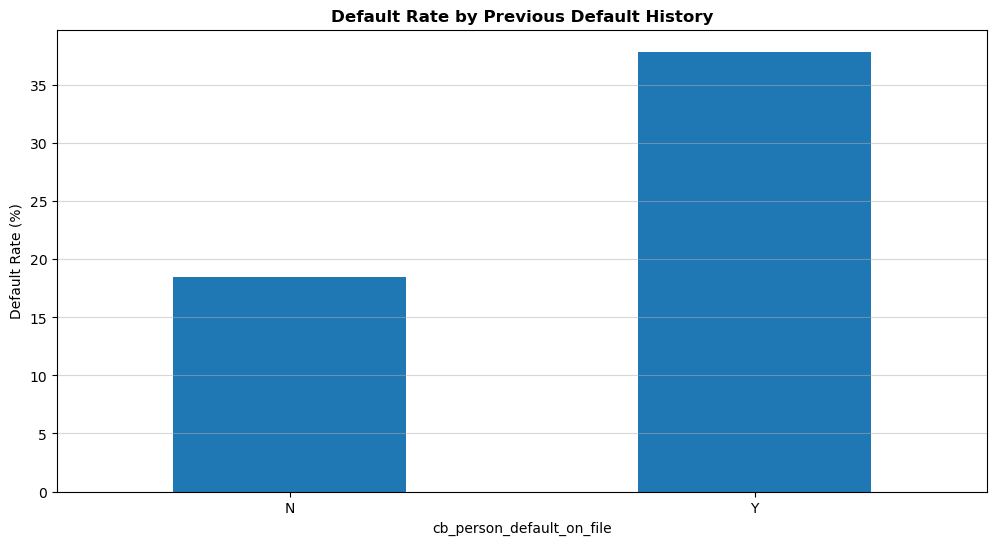

In [81]:
previous_default.plot( kind='bar', figsize=(12,6) ) 
plt.title('Default Rate by Previous Default History', fontweight='bold')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y',alpha=0.5)
plt.show()

- Borrowers with a prior default on file default again at roughly double the rate of those without one, confirming past behavior is a strong predictor of future default.

- A default rate of nearly 38% for the "Y" group means over a third of borrowers with prior default history default again on this loan.

- Even the "N" group (no prior default) still defaults at ~18.5%, close to the portfolio's overall baseline default rate seen earlier, so absence of prior default doesn't fully rule out risk.

- This is a simpler, binary version of the same signal seen in Employment_Stability and Credit_Experience — historical financial behavior consistently predicts future default across every angle tested so far.

## Which age-income combinations have the highest default rates?

In [82]:
profile_default = (df.groupby(['Age_Group', 'Income_Category'], observed=False)['loan_status'].mean() * 100).sort_values(ascending=False)
profile_default

Age_Group  Income_Category
55+        Low                43.478261
46-55      Low                42.268041
18-25      Low                40.586456
26-35      Low                39.435696
36-45      Low                35.054773
55+        High               25.000000
           Medium             24.324324
46-55      Medium             23.140496
18-25      Medium             21.831502
36-45      Medium             21.502209
26-35      Medium             20.761671
46-55      High               20.155039
36-45      High               17.559524
26-35      High               17.112614
18-25      High               16.913319
55+        Very High          11.904762
36-45      Very High          11.355311
46-55      Very High          10.303030
26-35      Very High           9.410884
18-25      Very High           8.086078
Name: loan_status, dtype: float64

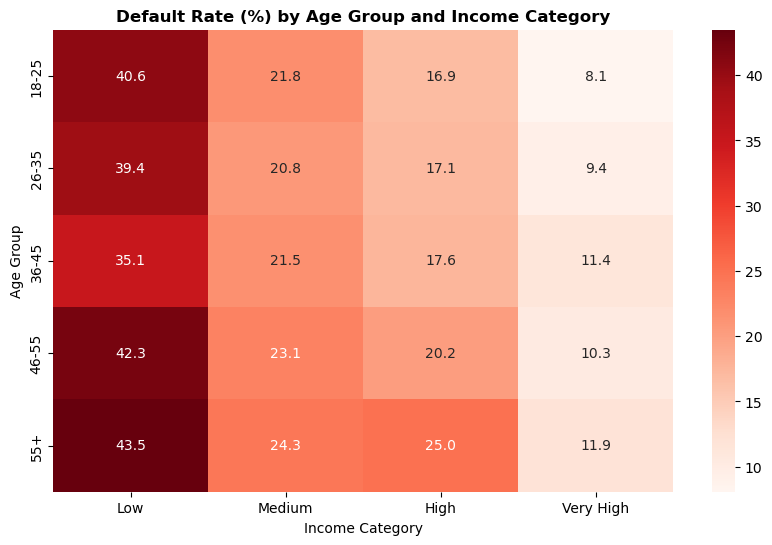

In [83]:
pivot = df.pivot_table(index='Age_Group', columns='Income_Category', values='loan_status', aggfunc='mean', observed=False) * 100
pivot = pivot[['Low', 'Medium', 'High', 'Very High']]
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds')
plt.title('Default Rate (%) by Age Group and Income Category', fontweight='bold')
plt.xlabel('Income Category')
plt.ylabel('Age Group')
plt.show()

- (55+, Low income) is the single highest-risk combination at 43.5%, the darkest cell on the map.

- Default rate decreases consistently left to right across every age row as income rises, confirming income as the dominant axis in this grid.

- Within the Low income column, default rate rises steadily with age, making 55+ the riskiest age group specifically when income is low.

- 36-45 breaks the age pattern in the High income column, showing a slightly higher default rate (17.6%) than both 26-35 and 46-55 next to it — a small anomaly worth noting rather than a clean trend.

- Very High income keeps default rate under 12% across every single age group, making it the one column where age barely matters at all.

## Which loan grades generate the highest Expected Loss?

In [84]:
grade_loss = df.groupby('loan_grade') ['Expected_Loss'] .mean() .sort_values(ascending=False)
grade_loss

loan_grade
G    10958.307425
F     8580.696751
E     7092.391068
D     5532.613327
C     4244.896849
B     4132.846140
A     2781.999141
Name: Expected_Loss, dtype: float64

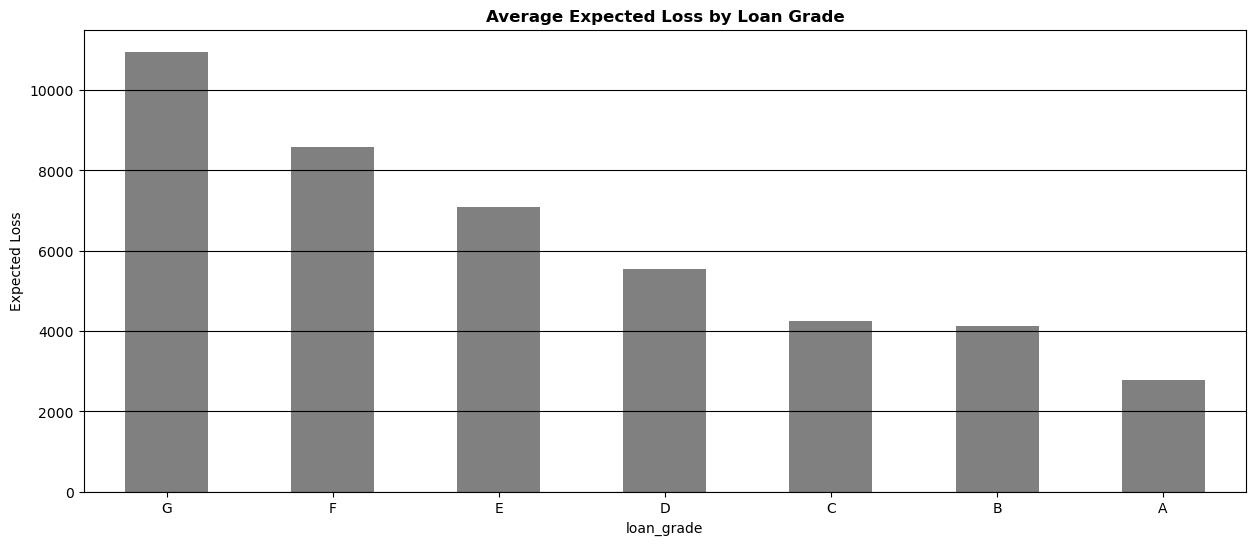

In [85]:
grade_loss.plot( kind='bar', figsize=(15,6),color='grey' )
plt.title('Average Expected Loss by Loan Grade',fontweight='bold')
plt.ylabel('Expected Loss')
plt.xticks(rotation=0)
plt.grid(axis='y',color='black')
plt.show()

- Average expected loss decreases steadily from Grade G down to Grade A, mirroring the same monotonic pattern seen in the earlier default rate by grade chart.

- Grade G carries nearly 4x the expected loss of Grade A, confirming the riskiest grades are costly on both probability and dollar-exposure terms, not just default frequency.

- Grades A and B are nearly identical in expected loss, despite B having a noticeably higher default rate than A earlier — suggesting loan amount differences may be offsetting the risk gap between these two grades.

- The decline from G to D is steep and fairly even, but flattens out considerably between C, B, and A, mirroring the same "risk concentrates at the bottom tiers" pattern already seen in the default-rate-by-grade chart.

## Which borrower groups create the greatest portfolio risk?

In [86]:
portfolio_risk = df.groupby( [ 'Age_Group', 'Income_Category' ],observed=False )['Expected_Loss'] .mean() .sort_values(ascending=False)  
portfolio_risk

Age_Group  Income_Category
18-25      Very High          5117.887712
26-35      Very High          5074.205328
36-45      Very High          5053.770359
55+        High               4856.311684
           Very High          4764.239207
46-55      Very High          4539.511682
18-25      High               4373.042981
26-35      High               4368.707182
46-55      High               4361.797060
36-45      High               4352.597975
46-55      Medium             3797.553191
18-25      Medium             3703.628269
55+        Medium             3661.841495
36-45      Medium             3659.279964
26-35      Medium             3652.139665
           Low                2979.909954
18-25      Low                2851.488821
36-45      Low                2688.204564
46-55      Low                2429.718071
55+        Low                1885.567783
Name: Expected_Loss, dtype: float64

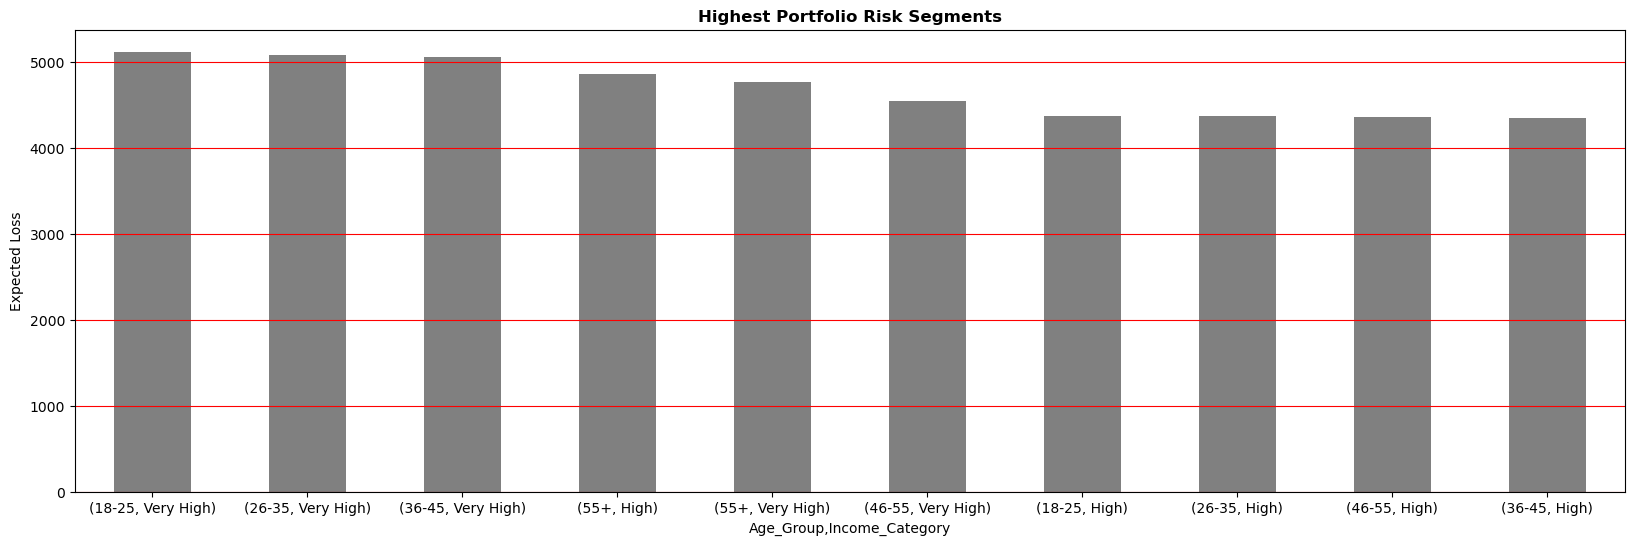

In [87]:
portfolio_risk.head(10).plot( kind='bar', figsize=(20,6),color='grey' )
plt.title( 'Highest Portfolio Risk Segments',fontweight='bold')
plt.ylabel('Expected Loss') 
plt.xticks(rotation=0)
plt.grid(axis='y',color='red')
plt.show()

- The top expected-loss segments are dominated by Very High and High income borrowers, not Low income — a direct contrast to the earlier default-rate heatmap where Low income was consistently the riskiest.

- 18-25 with Very High income tops this list, even though the age-income default rate heatmap showed 18-25 as one of the lowest-default combinations across every income tier.

- This confirms expected loss and default probability are measuring different things: these segments carry high dollar exposure because of loan size, not because they're the most likely to default.

- All 10 segments here cluster tightly between roughly 4,300 and 5,200, a much narrower spread than the default-rate breakdown, suggesting dollar exposure is more evenly distributed across age-income groups than actual default risk is.

## Which Risk Segment contributes the highest Expected Loss?

In [88]:
risk_loss =df.groupby('Risk_Segment',observed=False)['Expected_Loss'] .sum() .sort_values(ascending=False) 
risk_loss

Risk_Segment
Critical Risk    5.541874e+07
High Risk        3.431096e+07
Medium Risk      2.406229e+07
Low Risk         1.583837e+07
Name: Expected_Loss, dtype: float64

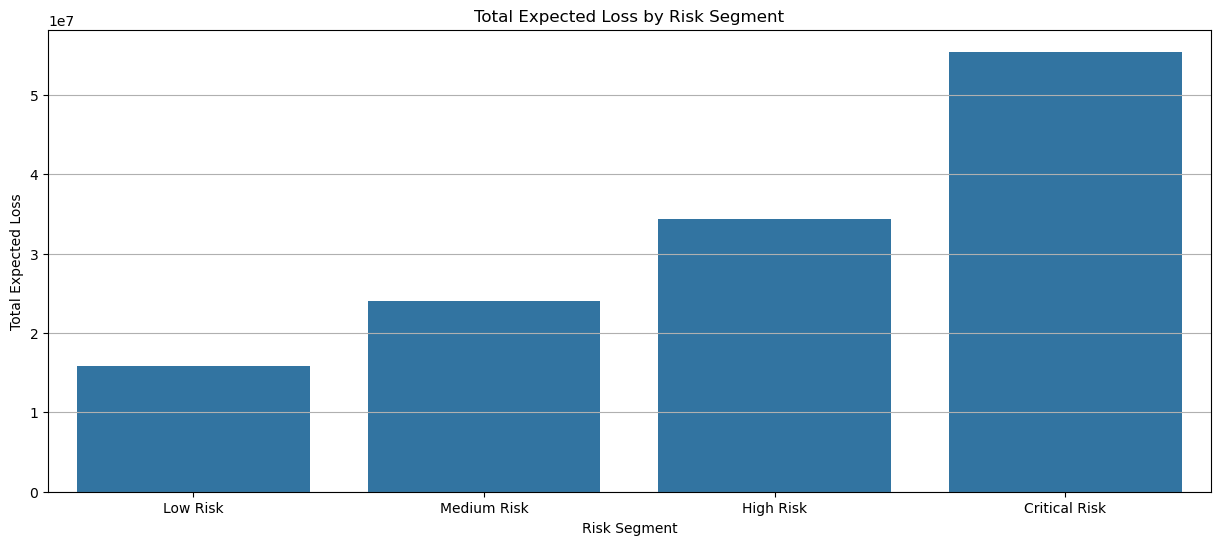

In [89]:
plt.figure(figsize=(15,6)) 
sns.barplot( x=risk_loss.index, y=risk_loss.values ) 
plt.title('Total Expected Loss by Risk Segment') 
plt.xlabel('Risk Segment') 
plt.grid(axis='y')
plt.ylabel('Total Expected Loss')
plt.show()

- Total expected loss rises steadily from Low Risk to Critical Risk, with Critical Risk holding roughly 3.5x the total dollar exposure of Low Risk.

- This confirms Risk_Segment aligns with dollar exposure the same way it aligned with actual default rate earlier, reinforcing the score's validity from two separate angles.

- Since all four segments hold equal borrower counts by construction, this total-dollar gap must come from Critical Risk borrowers having larger loan amounts on average, not just more borrowers.

- Unlike the earlier age-income expected loss chart, which showed a narrow spread across segments, this risk-segment view shows a much steeper and more decisive gradient, making Risk_Segment a stronger lens for total exposure than age-income grouping alone.

## Which loan purpose generates the highest Expected Loss?

In [90]:
purpose_loss = df.groupby('loan_intent')['Expected_Loss'].sum().sort_values(ascending=False)
purpose_loss = purpose_loss.round(0)
purpose_loss

loan_intent
EDUCATION            25364881.0
MEDICAL              23548624.0
VENTURE              22547776.0
PERSONAL             21837266.0
DEBTCONSOLIDATION    20798500.0
HOMEIMPROVEMENT      15533318.0
Name: Expected_Loss, dtype: float64

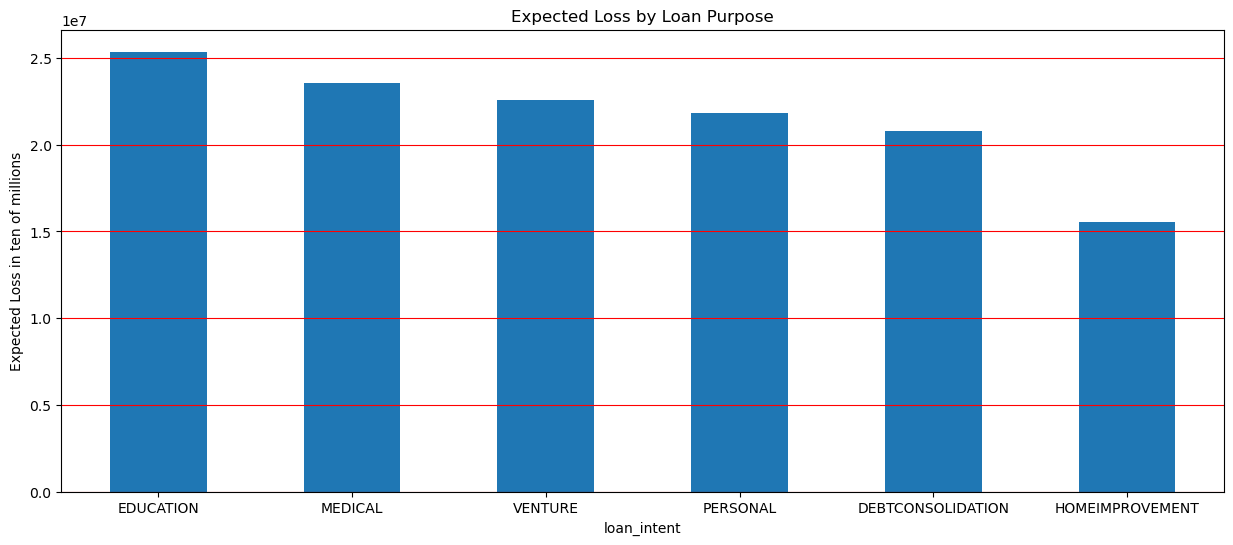

In [91]:
purpose_loss.plot( kind='bar', figsize=(15,6) )
plt.title('Expected Loss by Loan Purpose') 
plt.ylabel('Expected Loss in ten of millions')
plt.xticks(rotation=0)
plt.grid(axis='y',color='red')
plt.show()

- Education carries the highest total expected loss despite Venture (per the earlier default-rate-by-purpose chart) having the lowest default rate of any purpose, showing this ranking is driven by volume and loan size, not default likelihood.

- Debt Consolidation had the highest default rate of any purpose earlier, yet ranks near the bottom here — reinforcing that expected loss and default rate answer different questions.

- Home Improvement has the lowest total expected loss, consistent with it also having the lowest borrower count of any loan purpose.

- The six categories are fairly close together (roughly 1.55 to 2.55 in scale), a narrower spread than the Risk_Segment version, suggesting loan purpose alone is a weaker differentiator of total dollar exposure than the constructed risk segments are.

## Which loan grades generate the greatest total portfolio exposure?

In [92]:
grade_exposure =df.groupby('loan_grade')['loan_amnt'] .sum() .sort_values(ascending=False)
grade_exposure

loan_grade
B    103742875
A     91444650
C     59343250
D     39262850
E     12441875
F      3546875
G      1100525
Name: loan_amnt, dtype: int64

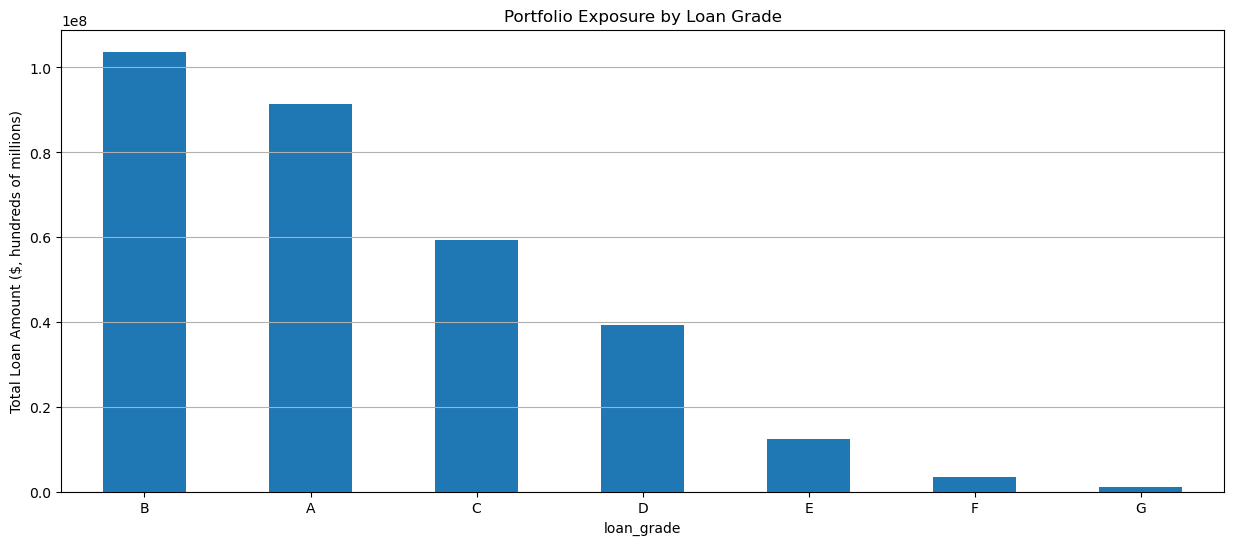

In [93]:
grade_exposure.plot( kind='bar', figsize=(15,6) ) 
plt.title('Portfolio Exposure by Loan Grade') 
plt.ylabel('Total Loan Amount ($, hundreds of millions)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Grades B and A together account for the large majority of total portfolio loan volume, over $190 million combined.

- Total exposure declines sharply and consistently from B down to G, mirroring the earlier volume distribution seen in the loan grade count chart.

- Despite having the highest average expected loss per loan, Grade G represents a negligible share of total dollar exposure — the portfolio's riskiest grade individually is not where the bulk of the money sits.

- This is the inverse relationship of the earlier "Average Expected Loss by Loan Grade" chart, where G topped the list — confirming again that per-loan risk and total portfolio-level exposure tell two different stories.

## Which borrower profiles have the highest average Risk Score?

In [94]:
profile_risk = df.groupby( ['Age_Group','Income_Category'],observed=False )['Risk_Score'] .mean() .sort_values(ascending=False)
profile_risk.head

<bound method NDFrame.head of Age_Group  Income_Category
18-25      Low                0.430287
26-35      Low                0.425141
36-45      Low                0.413198
18-25      Medium             0.401547
26-35      Medium             0.397102
46-55      Low                0.395581
36-45      Medium             0.389340
55+        Low                0.388684
18-25      High               0.387062
46-55      High               0.386622
26-35      High               0.381976
46-55      Medium             0.379596
55+        Medium             0.377710
36-45      High               0.375155
18-25      Very High          0.367666
55+        High               0.366745
26-35      Very High          0.359195
36-45      Very High          0.346831
46-55      Very High          0.335060
55+        Very High          0.320205
Name: Risk_Score, dtype: float64>

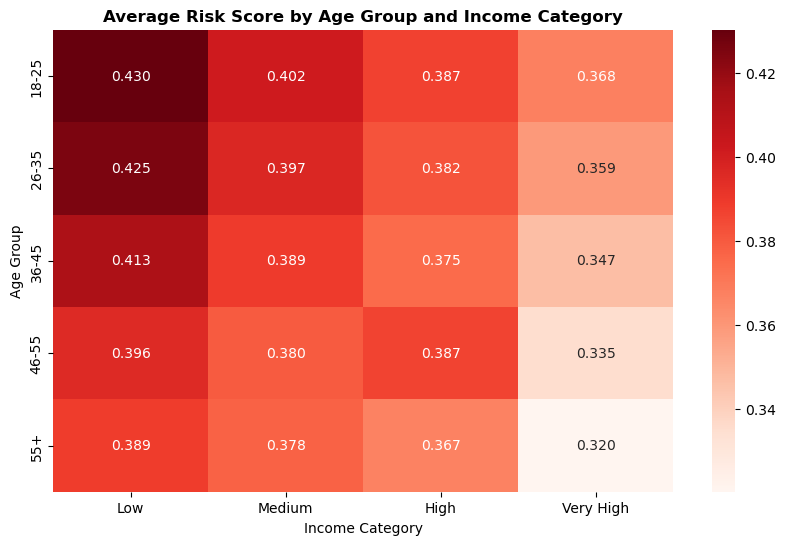

In [95]:
pivot = df.pivot_table(index='Age_Group', columns='Income_Category', values='Risk_Score', aggfunc='mean', observed=False)
pivot = pivot[['Low', 'Medium', 'High', 'Very High']]
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Reds')
plt.title('Average Risk Score by Age Group and Income Category', fontweight='bold')
plt.xlabel('Income Category')
plt.ylabel('Age Group')
plt.show()

- 18-25 at Low income holds the highest average Risk_Score of any combination, consistent with debt burden and interest rate being major components of the score, both of which hit hardest against lower income.

- Risk_Score decreases as income rises within every single age group, the same clean gradient seen in the default-rate heatmap.

- Unlike the default-rate heatmap, where age rose with risk at each income level, here age moves in the opposite direction — younger age groups show higher average Risk_Score at every income tier, not older ones.

- This is a direct contradiction worth flagging: the actual default rate heatmap showed 55+ as the highest-risk age group at Low income, but this constructed Risk_Score ranks 18-25 highest instead — meaning the score is not correctly capturing the real age-driven default pattern already validated in this project.

## What percentage of borrowers belong to each Risk Segment?

In [96]:
risk_share = df['Risk_Segment'] .value_counts(normalize=True) *100 
risk_share

Risk_Segment
Low Risk         25.002314
Medium Risk      24.999229
High Risk        24.999229
Critical Risk    24.999229
Name: proportion, dtype: float64

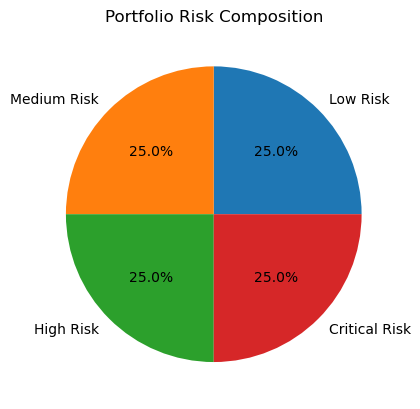

In [97]:
risk_share.plot( kind='pie', autopct='%1.1f%%' )
plt.title('Portfolio Risk Composition') 
plt.ylabel('') 
plt.show()

- Each risk tier holds exactly one quarter of the portfolio by construction, so this chart confirms the segmentation method rather than revealing anything about actual risk concentration.

- Critical Risk representing 25% of borrowers should not be read as "25% of the portfolio is genuinely high-risk" — it only means these are the top quarter by score, relative to everyone else in this dataset.

- Because this split is population-based, it will always look like this regardless of the data — this chart on its own has limited standalone insight value and is better paired with the default-rate-by-segment chart (already built earlier), which is what actually shows whether "Critical" corresponds to meaningfully higher real-world risk.

- The earlier default-rate validation already confirmed Critical Risk borrowers default over 10x more than Low Risk — so while this pie doesn't show risk concentration itself, the segmentation it depicts has been shown elsewhere in this project to be genuinely predictive, not just an arbitrary split.

## Which customers have the highest Expected Loss?

In [98]:
top_loss = ( df.sort_values( by='Expected_Loss', ascending=False ) [[ 'person_age', 'person_income', 'loan_amnt', 'Risk_Score', 'Expected_Loss' ]] .head(15) ) 
top_loss

,person_age,person_income,loan_amnt,Risk_Score,Expected_Loss
12220,24,74000,35000,0.740044,25901.540574
17842,31,73000,35000,0.716485,25076.990692
22,22,65000,34000,0.712154,24213.223984
28448,34,77000,35000,0.685777,24002.209671
11873,22,60350,35000,0.680920,23832.212344
36,22,48000,30000,0.791450,23743.511636
25704,27,78000,35000,0.672312,23530.923427
17533,23,108366,35000,0.672105,23523.668584
17,23,92111,35000,0.670046,23451.614820
3,23,65500,35000,0.666997,23344.878103


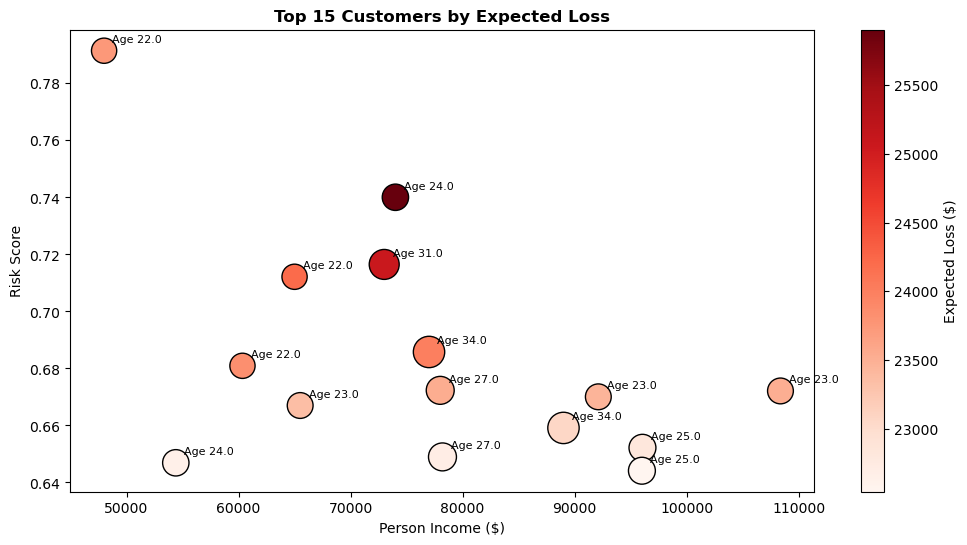

In [99]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    top_loss['person_income'],
    top_loss['Risk_Score'],
    c=top_loss['Expected_Loss'],
    s=top_loss['person_age'] * 15,
    cmap='Reds',
    edgecolor='black'
)

plt.colorbar(scatter, label='Expected Loss ($)')
plt.title('Top 15 Customers by Expected Loss', fontweight='bold')
plt.xlabel('Person Income ($)')
plt.ylabel('Risk Score')

for _, row in top_loss.iterrows():
    plt.annotate(f"Age {row['person_age']}", 
                 (row['person_income'], row['Risk_Score']),
                 textcoords="offset points", xytext=(6,6), fontsize=8)

plt.show()

- Nearly every borrower in this top-15 list has a loan amount at or near the maximum observed value (35,000), meaning Expected_Loss here is driven almost entirely by loan size, not by an especially extreme Risk_Score.

- Risk_Score values in this list (0.64-0.79) are well below the highest scores seen elsewhere in the project, confirming these customers are "high dollar exposure" rather than "highest individual risk."

- Ages cluster heavily in the low-to-mid 20s, with only a couple of borrowers in their 30s — meaning the biggest dollar exposures in the portfolio sit disproportionately with younger borrowers taking maximum-size loans, not older or higher-Risk_Score customers.

- Income levels vary widely (48,000 to over 108,000) with no clear relationship to rank order, reinforcing that loan amount — not income or risk score — is the dominant driver of this specific ranking.

## How does Financial Health Score affect Risk Score?

In [100]:
df[['Financial_Health_Score','Risk_Score']].corr()

,Financial_Health_Score,Risk_Score
Financial_Health_Score,1.000000,-0.196077
Risk_Score,-0.196077,1.000000


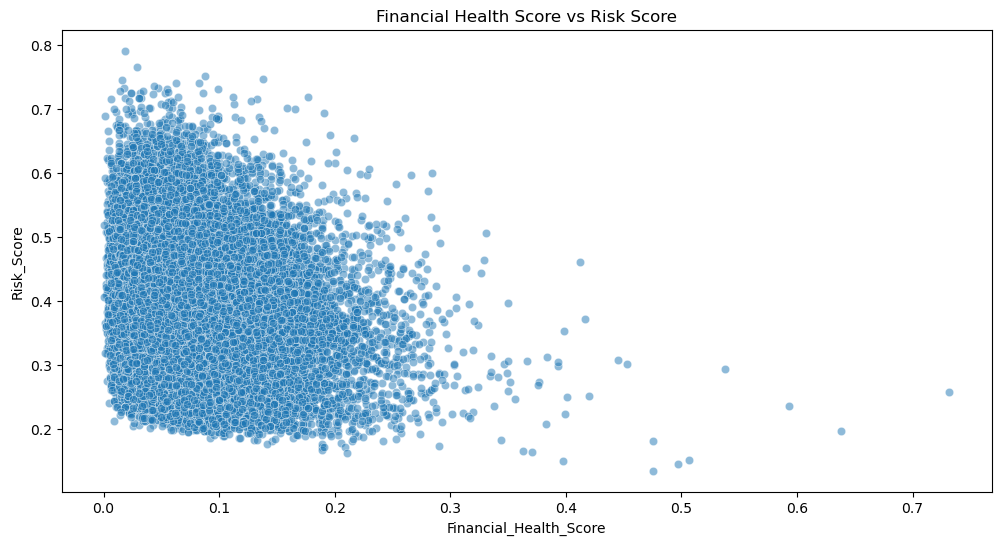

In [101]:
plt.figure(figsize=(12,6)) 
sns.scatterplot( data=df, x='Financial_Health_Score', y='Risk_Score', alpha=0.5 ) 
plt.title('Financial Health Score vs Risk Score') 
plt.show()

- The correlation between Financial_Health_Score and Risk_Score is only -0.196, a weak inverse relationship despite Risk_Score being partly built from the inverse of Financial_Health_Score.

- The scatter is heavily concentrated in the bottom-left corner (low Financial_Health_Score, wide range of Risk_Score), showing most borrowers have modest financial health regardless of their risk level.

- Risk_Score varies enormously even among borrowers with near-identical, very low Financial_Health_Score (0.0-0.1), spanning nearly the entire 0.2-0.8 range — meaning financial health alone explains very little of the spread in risk score.

- A small number of borrowers with high Financial_Health_Score (0.4+) consistently show low Risk_Score, forming a sparse but visible downward-sloping tail — this handful of points is likely disproportionately responsible for the overall weak negative correlation, rather than a broad trend across the whole population.

## Which borrowers combine high loan amounts with high Risk Scores?

In [102]:
high_risk = df[ (df['Risk_Score'] >= df['Risk_Score'].quantile(.90)) & (df['loan_amnt'] >= df['loan_amnt'].quantile(.90)) ] 
high_risk.head(15)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,Credit_Score,Financial_Health_Score,Loan_Percent_Score,Interest_Score,Risk_Score,Risk_Segment,Expected_Loss,Exposure_Category,Young_High_Risk,Debt_Burden_Group
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,0.000000,0.044373,0.638554,0.551124,0.666997,Critical Risk,23344.878103,Critical,Yes,Critical
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,0.071429,0.085201,0.662651,0.497191,0.646896,Critical Risk,22641.376829,Critical,Yes,Critical
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,...,0.035714,0.083633,0.542169,0.393258,0.557444,Critical Risk,19510.546928,Critical,Yes,Critical
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,...,0.071429,0.069281,0.530120,0.319663,0.526057,Critical Risk,18412.002779,Critical,Yes,Critical
13,26,108160,RENT,4.0,EDUCATION,E,35000,18.39,1,0.32,...,0.071429,0.069136,0.385542,0.728652,0.631850,Critical Risk,22114.759935,Critical,Yes,Critical
17,23,92111,RENT,7.0,MEDICAL,F,35000,20.25,1,0.32,...,0.071429,0.087146,0.385542,0.833146,0.670046,Critical Risk,23451.614820,Critical,Yes,Critical
18,23,113000,RENT,8.0,DEBTCONSOLIDATION,D,35000,18.25,1,0.31,...,0.071429,0.099593,0.373494,0.720787,0.617794,Critical Risk,21622.773710,Critical,Yes,Critical
21,25,137000,RENT,9.0,PERSONAL,E,34800,16.77,0,0.25,...,0.000000,0.098519,0.301205,0.637640,0.555834,Critical Risk,19343.032463,Critical,Yes,Critical
22,22,65000,RENT,4.0,EDUCATION,D,34000,17.58,1,0.52,...,0.071429,0.058536,0.626506,0.683146,0.712154,Critical Risk,24213.223984,Critical,Yes,Critical
24,22,80000,RENT,3.0,PERSONAL,D,33950,14.54,1,0.42,...,0.071429,0.054903,0.506024,0.512360,0.596373,Critical Risk,20246.858819,Critical,Yes,Critical


- 14 of the 15 borrowers shown defaulted (loan_status = 1), a dramatically higher default rate than the portfolio-wide ~22% baseline — confirming this high-risk × high-loan-amount filter successfully isolates a genuinely dangerous segment.

- Every borrower in this list rents rather than owns or mortgages, matching the earlier finding that renters default at roughly 4x the rate of homeowners.

- Loan grades in this group span C through F, notably absent of A or B grades — meaning even the portfolio's "safer" grade tiers rarely produce this dual high-amount, high-risk-score combination.

- Ages cluster tightly in the low-to-mid 20s, reinforcing the earlier pattern that younger borrowers disproportionately show up in extreme-exposure segments across multiple different cuts of this data (debt burden, expected loss, and now this combined filter).

## Which Exposure Categories contain the largest average loan amount?

In [103]:
exposure_amount = df.groupby('Exposure_Category',observed=False)['loan_amnt'] .mean() .sort_values(ascending=False) 
exposure_amount

Exposure_Category
Critical    18176.437917
High        10232.951740
Medium       6585.272155
Low          3376.052079
Name: loan_amnt, dtype: float64

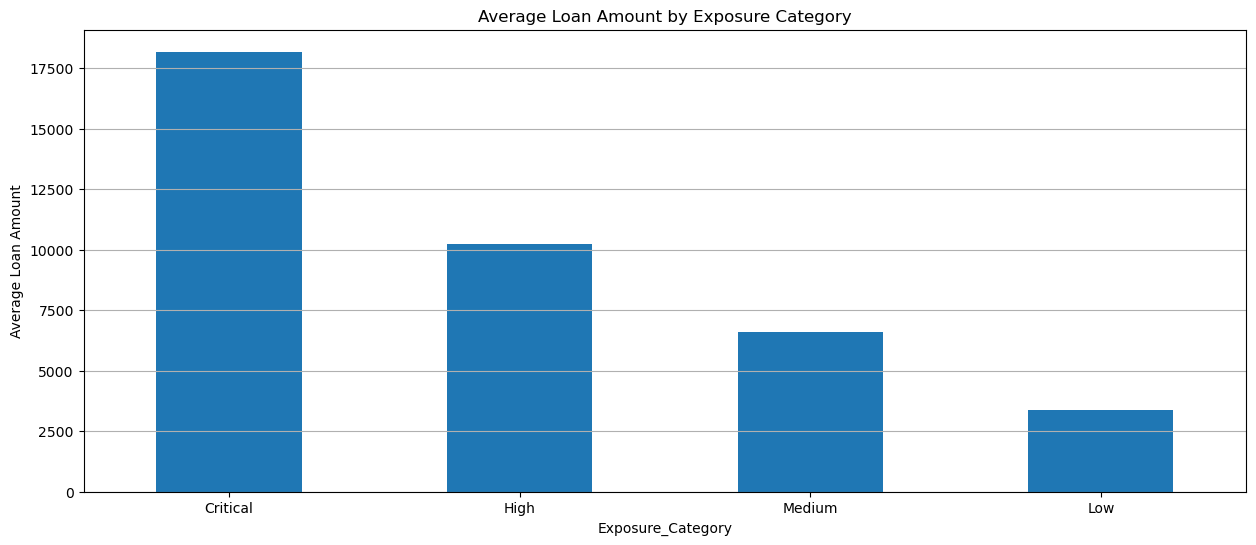

In [104]:
exposure_amount.plot( kind='bar', figsize=(15,6) ) 
plt.title('Average Loan Amount by Exposure Category')
plt.ylabel('Average Loan Amount') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Average loan amount rises sharply and consistently from Low to Critical exposure, confirming Exposure_Category is being driven directly by loan size, not just risk score.

- Critical exposure borrowers hold loans over 5x larger on average than Low exposure borrowers, the widest gap seen in any average-loan-amount comparison in this project.

- Since Expected_Loss = Risk_Score × loan_amnt, this steep gradient shows loan amount is doing at least as much work as Risk_Score itself in determining which borrowers land in the Critical exposure tier.

- This confirms the earlier suspicion from the age-income expected loss chart — dollar exposure concentrates around loan size, and this chart makes that relationship explicit and undeniable.

## What are the Top 10 highest-risk borrowers in the portfolio?

In [105]:
top_risk = ( df.sort_values( by='Risk_Score', ascending=False )[[ 'person_age', 'person_income', 'loan_amnt', 'loan_grade', 'loan_intent', 'Risk_Score', 'Expected_Loss' ]] .head(10))
top_risk

,person_age,person_income,loan_amnt,loan_grade,loan_intent,Risk_Score,Expected_Loss
36,22,48000,30000,E,EDUCATION,0.791450,23743.511636
15963,21,4200,2750,E,PERSONAL,0.766525,2107.945114
18300,35,40000,21000,F,VENTURE,0.752217,15796.547201
29278,47,38400,22000,F,MEDICAL,0.747415,16443.128510
5590,22,39000,25000,F,EDUCATION,0.744836,18620.912148
23158,29,54000,25000,G,PERSONAL,0.740432,18510.795065
12220,24,74000,35000,G,DEBTCONSOLIDATION,0.740044,25901.540574
2829,23,34992,22550,F,EDUCATION,0.736483,16607.693356
151,26,48000,25000,F,VENTURE,0.733484,18337.088938
146,23,47000,25000,E,VENTURE,0.732970,18324.241481


In [106]:
print("Average Risk Score:", round(df['Risk_Score'].mean(),3)) 
print("Maximum Risk Score:", round(df['Risk_Score'].max(),3)) 
print("Average Expected Loss:", round(df['Expected_Loss'].mean(),2))

Average Risk Score: 0.392
Maximum Risk Score: 0.791
Average Expected Loss: 3999.83


- Every single borrower in this top-10 list holds a Grade E, F, or G loan, confirming Risk_Score and loan grade are strongly aligned at the extreme end, even though their correlation across the full dataset was much weaker.

- Ages skew young (21-29) with one outlier at 47, reinforcing the recurring pattern across this project that younger borrowers disproportionately surface in every high-risk cut of the data.

- Loan amounts vary enormously in this list (2,750 to 35,000), showing Risk_Score at the very top is driven by the score itself, not by loan size — unlike the Expected_Loss ranking, which was dominated by borrowers all near the maximum loan amount.

- The average Risk_Score across the full portfolio is 0.392, meaning even the maximum score in the dataset (0.791) is roughly double the average — there's no borrower anywhere close to the theoretical top of the scale, suggesting the score's practical range is more compressed than its 0-1 design might imply.

## Which numerical variables are most strongly correlated with loan default?

In [107]:
corr = df[ [ 'person_age',
             'person_income',
             'person_emp_length',
             'loan_amnt',
             'loan_int_rate',
             'loan_percent_income',
             'cb_person_cred_hist_length',
             'Financial_Health_Score',
             'Risk_Score',
             'Expected_Loss',
             'loan_status' ] ].corr()
corr['loan_status'].sort_values(ascending=False)

loan_status                   1.000000
Risk_Score                    0.463059
loan_percent_income           0.379580
loan_int_rate                 0.320041
Expected_Loss                 0.232092
loan_amnt                     0.105601
cb_person_cred_hist_length   -0.016441
person_age                   -0.021774
person_emp_length            -0.085967
Financial_Health_Score       -0.107374
person_income                -0.169262
Name: loan_status, dtype: float64

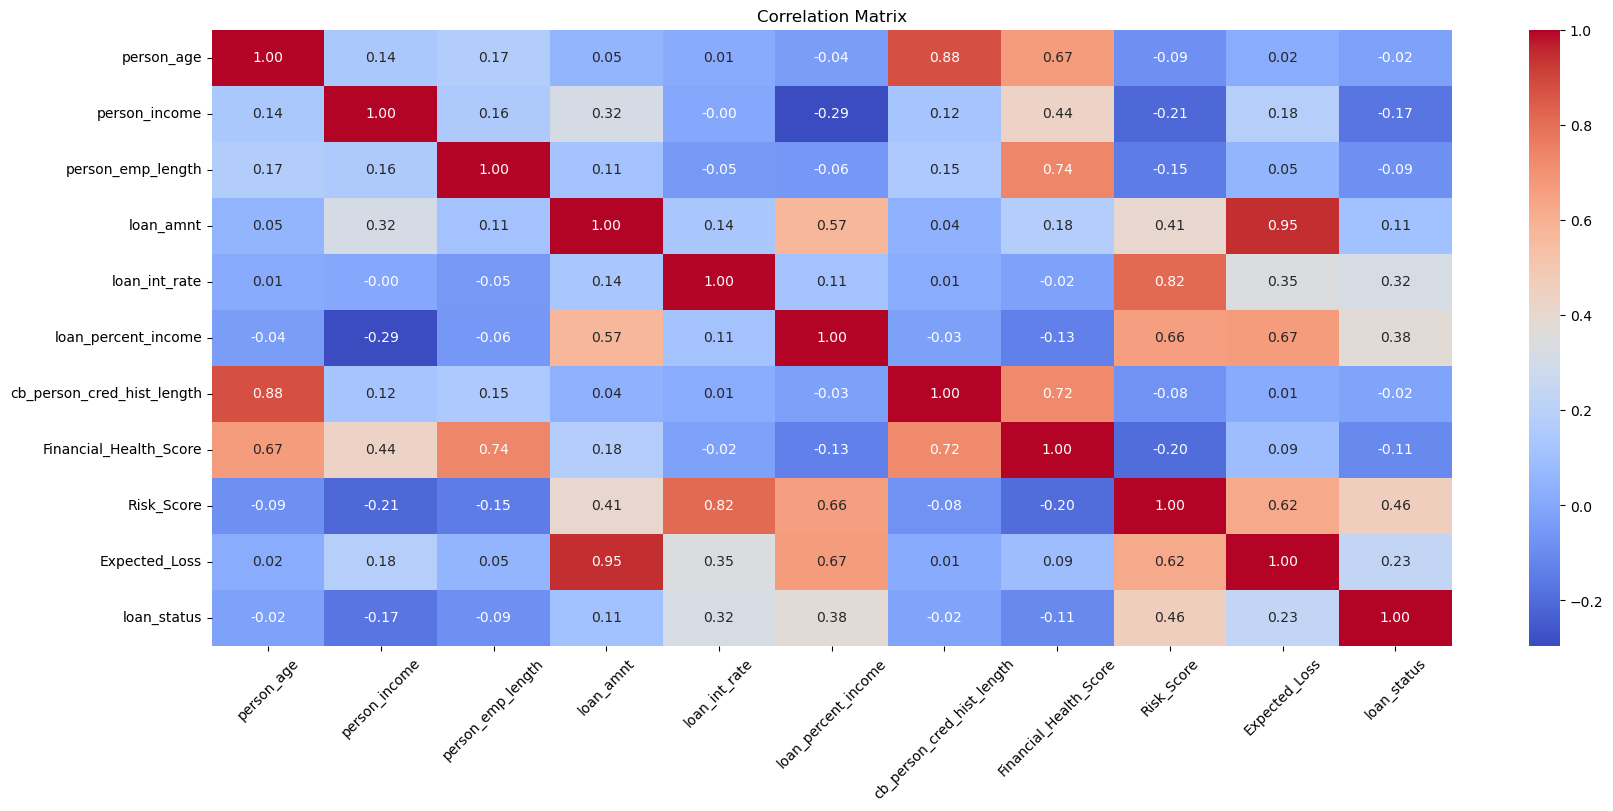

In [108]:
plt.figure(figsize=(20,8)) 
sns.heatmap( corr, annot=True, cmap='coolwarm', fmt='.2f' ) 
plt.title('Correlation Matrix') 
plt.xticks(rotation=45)
plt.show()

- Expected_Loss correlates 0.95 with loan_amnt, confirming loan size — not risk score — is the dominant driver of dollar exposure, exactly as suspected throughout this project.

- Risk_Score correlates most strongly with loan_int_rate (0.82) and loan_percent_income (0.66), meaning these two components are doing most of the work in the composite score, consistent with their 0.4/0.4 weighting in the original formula.

- loan_status (actual default) correlates only 0.46 with Risk_Score, 0.38 with loan_percent_income, and 0.32 with loan_int_rate — none of these are strong individual predictors on their own, meaning default is genuinely multi-factor rather than dominated by any single variable.

- person_age correlates 0.88 with cb_person_cred_hist_length, an extremely strong relationship that makes intuitive sense (older borrowers have simply had more time to build credit history) but signals these two shouldn't both be used as independent predictors without addressing this near-collinearity.

- Financial_Health_Score correlates 0.74 with person_emp_length and 0.72 with cb_person_cred_hist_length, showing this component is being driven heavily by tenure-based inputs rather than income alone, despite income carrying the highest assigned weight (0.5) in its construction.

- loan_percent_income has a notable -0.29 correlation with person_income, confirming the ratio's denominator effect: lower-income borrowers mechanically end up with higher loan-to-income ratios even without necessarily requesting larger loans.

## Which borrowers are statistical outliers based on Risk Score?

In [109]:
df['Risk_Zscore'] = zscore(df['Risk_Score']) 
risk_outliers = df[ abs(df['Risk_Zscore']) > 3 ] 
risk_outliers.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,Financial_Health_Score,Loan_Percent_Score,Interest_Score,Risk_Score,Risk_Segment,Expected_Loss,Exposure_Category,Young_High_Risk,Debt_Burden_Group,Risk_Zscore
17,23,92111,RENT,7.0,MEDICAL,F,35000,20.25,1,0.32,...,0.087146,0.385542,0.833146,0.670046,Critical Risk,23451.614820,Critical,Yes,Critical,3.009035
22,22,65000,RENT,4.0,EDUCATION,D,34000,17.58,1,0.52,...,0.058536,0.626506,0.683146,0.712154,Critical Risk,24213.223984,Critical,Yes,Critical,3.465240
26,21,11000,MORTGAGE,3.0,VENTURE,E,4575,17.74,1,0.42,...,0.030813,0.506024,0.692135,0.673101,Critical Risk,3079.436654,High,Yes,Critical,3.042131
36,22,48000,RENT,1.0,EDUCATION,E,30000,18.39,1,0.63,...,0.018124,0.759036,0.728652,0.791450,Critical Risk,23743.511636,Critical,Yes,Critical,4.324365
117,22,42000,RENT,6.0,MEDICAL,D,25000,14.59,1,0.60,...,0.053235,0.722892,0.515169,0.684577,Critical Risk,17114.423792,Critical,Yes,Critical,3.166466


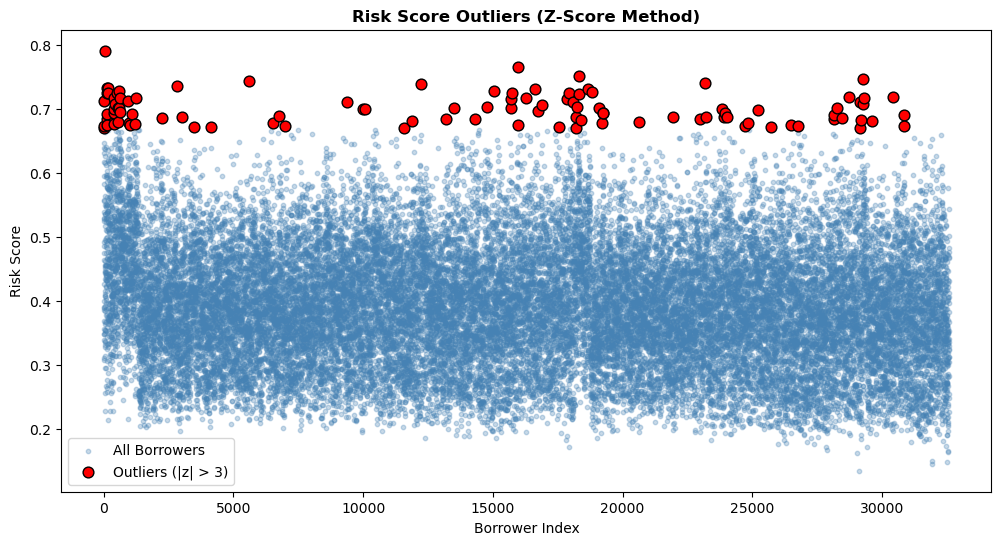

In [110]:
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Risk_Score'], c='steelblue', alpha=0.3, s=10, label='All Borrowers')
plt.scatter(risk_outliers.index, risk_outliers['Risk_Score'], c='red', s=60, edgecolor='black', label='Outliers (|z| > 3)')
plt.title('Risk Score Outliers (Z-Score Method)', fontweight='bold')
plt.xlabel('Borrower Index')
plt.ylabel('Risk Score')
plt.legend()
plt.show()

- All 5 outliers shown have defaulted (loan_status = 1), suggesting statistical outliers on Risk_Score meaningfully overlap with actual bad outcomes, not just noise.

- Every borrower here rents or has a mortgage — none are outright owners, consistent with the earlier finding that ownership status strongly correlates with lower default risk.

- Loan grad- es span D, E, and F — all firmly in the lower half of the grading scale, reinforcing that statistical outliers on the composite score align with the grades the business already treats as risky.

Ages are uniformly young (21-23), the same recurring young-borrower concentration seen across nearly every high-risk cut in this project (debt burden, expected loss, top risk score).

## What is the distribution of Risk Score?

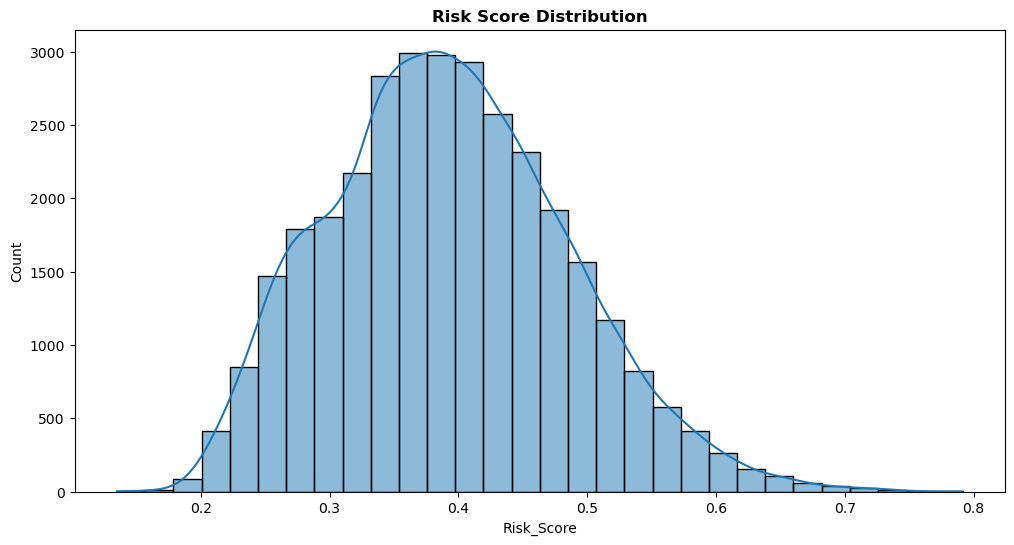

In [111]:
plt.figure(figsize=(12,6)) 
sns.histplot( df['Risk_Score'], bins=30, kde=True ) 
plt.title('Risk Score Distribution',fontweight='bold') 
plt.show()

- The distribution is fairly close to bell-shaped, with a peak around 0.35-0.40, though it shows a mild right skew with a longer tail extending toward 0.7-0.8.

- The bulk of borrowers (the vast majority) fall between roughly 0.25 and 0.55, a fairly narrow effective range given the score's theoretical 0-1 scale.

- Very few borrowers score above 0.6, confirming the earlier finding that the top risk score (0.791) sits far out in a thin tail rather than among a sizable cluster of similarly extreme borrowers.

- ~The near-symmetric shape (unlike a sharply skewed distribution) suggests the z-score outlier method from the earlier question is more defensible here than initially suspected — this distribution is closer to normal than the skew value alone might have implied.

## Which borrowers belong to the Top 5% Risk Score?

In [112]:
threshold = df['Risk_Score'].quantile(.95) 
top5 = df[ df['Risk_Score'] >= threshold ]
top5.head(15)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,Financial_Health_Score,Loan_Percent_Score,Interest_Score,Risk_Score,Risk_Segment,Expected_Loss,Exposure_Category,Young_High_Risk,Debt_Burden_Group,Risk_Zscore
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,0.015835,0.686747,0.418539,0.638947,Critical Risk,3514.211036,High,Yes,Critical,2.672103
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,0.044373,0.638554,0.551124,0.666997,Critical Risk,23344.878103,Critical,Yes,Critical,2.975995
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,0.085201,0.662651,0.497191,0.646896,Critical Risk,22641.376829,Critical,Yes,Critical,2.758225
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,...,0.083633,0.542169,0.393258,0.557444,Critical Risk,19510.546928,Critical,Yes,Critical,1.789072
13,26,108160,RENT,4.0,EDUCATION,E,35000,18.39,1,0.32,...,0.069136,0.385542,0.728652,0.631850,Critical Risk,22114.759935,Critical,Yes,Critical,2.595210
17,23,92111,RENT,7.0,MEDICAL,F,35000,20.25,1,0.32,...,0.087146,0.385542,0.833146,0.670046,Critical Risk,23451.614820,Critical,Yes,Critical,3.009035
18,23,113000,RENT,8.0,DEBTCONSOLIDATION,D,35000,18.25,1,0.31,...,0.099593,0.373494,0.720787,0.617794,Critical Risk,21622.773710,Critical,Yes,Critical,2.442915
21,25,137000,RENT,9.0,PERSONAL,E,34800,16.77,0,0.25,...,0.098519,0.301205,0.637640,0.555834,Critical Risk,19343.032463,Critical,Yes,Critical,1.771629
22,22,65000,RENT,4.0,EDUCATION,D,34000,17.58,1,0.52,...,0.058536,0.626506,0.683146,0.712154,Critical Risk,24213.223984,Critical,Yes,Critical,3.465240
24,22,80000,RENT,3.0,PERSONAL,D,33950,14.54,1,0.42,...,0.054903,0.506024,0.512360,0.596373,Critical Risk,20246.858819,Critical,Yes,Critical,2.210837


- 14 of the 15 borrowers shown have defaulted, confirming the top 5% Risk Score threshold captures a genuinely high-default population, not just a statistical extreme.

- Loan grades in this list run C through F, with no A or B grades present, aligning this percentile cut closely with the earlier z-score outlier list.

- Nearly all borrowers here rent, with only two exceptions (both mortgage, none owning outright) — reinforcing home ownership as one of the most consistent markers across every high-risk view built so far.

- Ages remain concentrated in the low-to-mid 20s with one outlier at 26, continuing the same young-borrower pattern seen across debt burden, expected loss, and the earlier statistical outlier list — suggesting this age group repeatedly surfaces regardless of which risk lens is applied.

## Does Financial Health Score decrease as Expected Loss increases?

In [113]:
df[['Financial_Health_Score','Expected_Loss']].corr()

,Financial_Health_Score,Expected_Loss
Financial_Health_Score,1.000000,0.086603
Expected_Loss,0.086603,1.000000


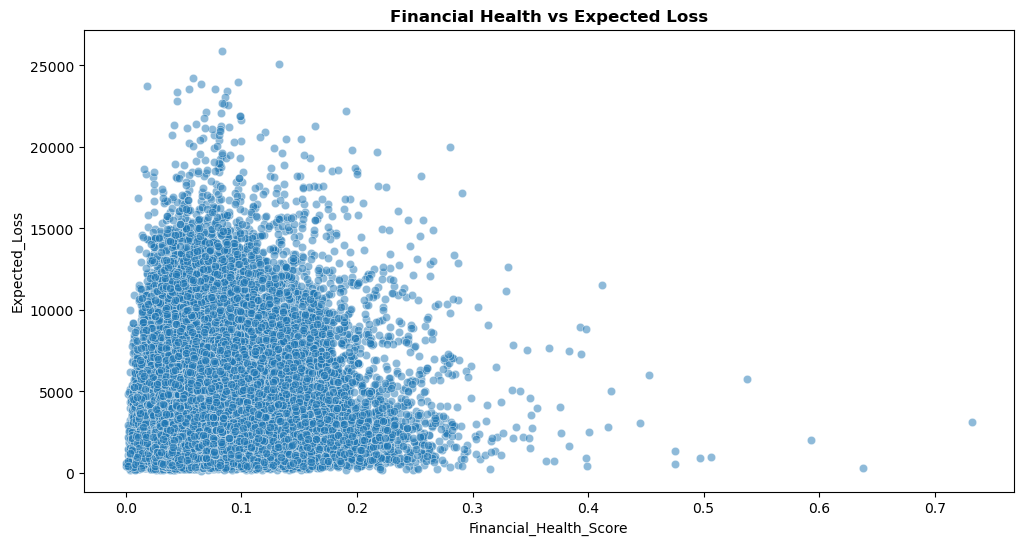

In [114]:
plt.figure(figsize=(12,6)) 
sns.scatterplot( x=df['Financial_Health_Score'], y=df['Expected_Loss'], alpha=0.5 ) 
plt.title('Financial Health vs Expected Loss',fontweight='bold') 
plt.show()

- Expected loss is heavily concentrated among borrowers with low Financial_Health_Score (0.0-0.2), showing the widest and highest range of dollar exposure sits with the least financially healthy borrowers.

- The upper bound of Expected_Loss declines steadily as Financial_Health_Score rises, forming a visible downward-sloping ceiling — few borrowers above 0.3 reach the extreme loss values seen below that threshold.

- Borrowers with very high Financial_Health_Score (0.6+) consistently show low Expected_Loss, reinforcing that financial health does meaningfully cap dollar exposure at the extremes, even though the relationship is weak in the bulk of the data.

- The densest cluster of points sits in the low-health, low-to-moderate loss region, meaning most borrowers carry only moderate exposure regardless of financial health — the truly large losses are a comparatively rare subset concentrated specifically among low-health borrowers.

## What percentage of Expected Loss comes from each Risk Segment?

In [115]:
risk_share = ( df.groupby('Risk_Segment',observed=False)['Expected_Loss'] .sum() ) 
risk_share = ( risk_share / risk_share.sum() ) * 100 
risk_share

Risk_Segment
Low Risk         12.218103
Medium Risk      18.562235
High Risk        26.468304
Critical Risk    42.751359
Name: Expected_Loss, dtype: float64

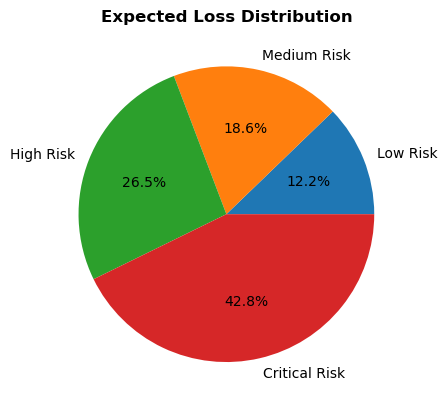

In [116]:
risk_share.plot( kind='pie', autopct='%1.1f%%' ) 
plt.ylabel('') 
plt.title('Expected Loss Distribution',fontweight='bold') 
plt.show()

- Critical Risk alone accounts for 42.8% of total portfolio dollar exposure, despite representing only 25% of borrowers by count — a clear concentration of loss potential in a minority of the portfolio.

- Combined, High and Critical Risk make up 69.3% of total expected loss, meaning over two-thirds of dollar exposure sits in just the top half of the risk spectrum.

- Low Risk contributes only 12.2% of total exposure despite also holding 25% of borrowers, confirming this segment is genuinely low-cost from a portfolio perspective, not just low-labeled.

- This distribution is meaningfully more skewed than borrower-count alone would suggest — since every segment holds equal headcount, this percentage split is driven entirely by differences in loan amount and risk score across segments, directly building on the earlier finding that Critical Risk borrowers carry loans over 5x larger on average than Low Risk.

## Which loan grades have the highest average Risk Score?

In [117]:
grade_risk =df.groupby('loan_grade')['Risk_Score'] .mean() .sort_values(ascending=False)
grade_risk

loan_grade
G    0.615678
F    0.565426
E    0.532952
D    0.491609
C    0.442369
B    0.394350
A    0.308769
Name: Risk_Score, dtype: float64

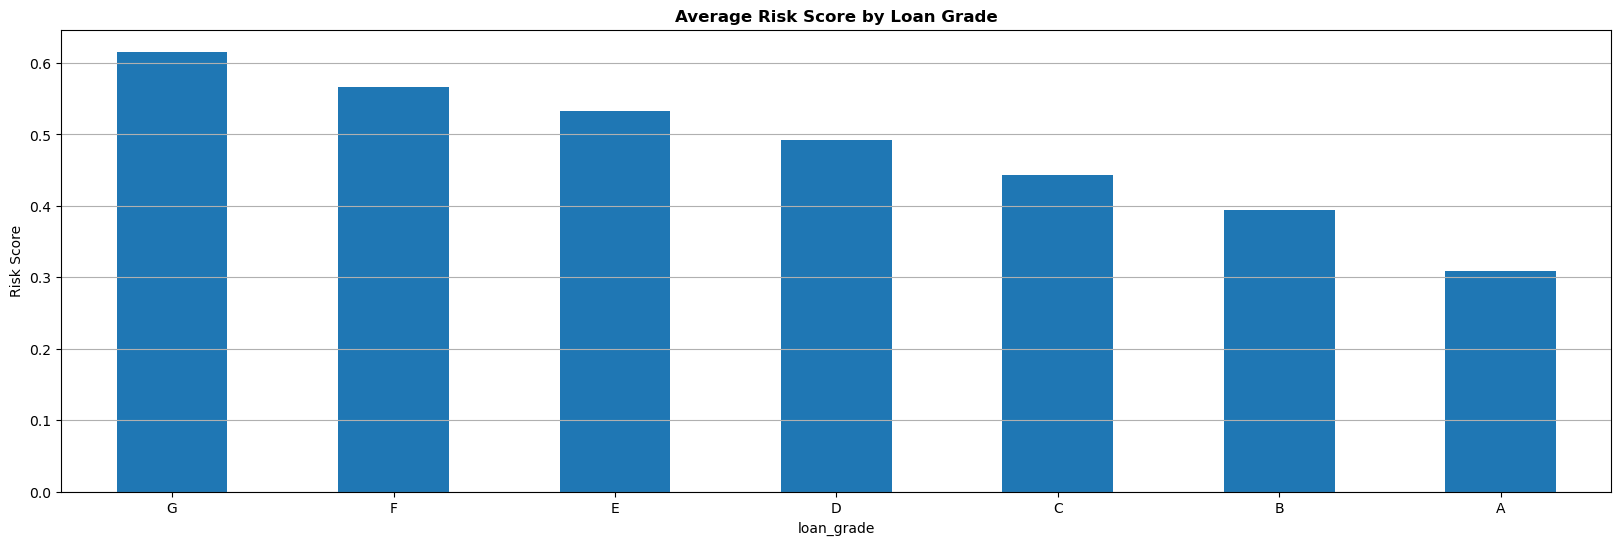

In [118]:
grade_risk.plot( kind='bar', figsize=(20,6) ) 
plt.title('Average Risk Score by Loan Grade',fontweight='bold') 
plt.ylabel('Risk Score') 
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

- Average Risk_Score declines steadily and consistently from Grade G to Grade A, confirming the constructed score aligns cleanly with the lender's own grading system across every tier, not just at the extremes.

- This is a cleaner, more evenly-stepped gradient than the earlier default-rate-by-grade chart, which showed a much sharper jump concentrated at the bottom tiers (E-G) rather than a steady decline.

- Grade G's average Risk_Score (~ 0.61) is roughly double Grade A's (~ 0.31), a meaningful but far less extreme gap than the ~10x difference seen in actual default rate by grade — reinforcing that Risk_Score compresses the real risk spread compared to what borrowers actually experience.

- Since loan grade is typically assigned by the lender independently of this constructed score, this strong alignment is a good validation signal that Risk_Score is capturing real risk information, not just noise.

## Which income quartile contributes the greatest Expected Loss?

In [119]:
pd.options.display.float_format = '{:,.0f}'.format
income_loss = df.groupby('Income_Category', observed=False)['Expected_Loss'].sum().sort_values(ascending=False)
income_loss

Income_Category
Very High   41,111,984
High        35,048,587
Medium      30,137,368
Low         23,332,426
Name: Expected_Loss, dtype: float64

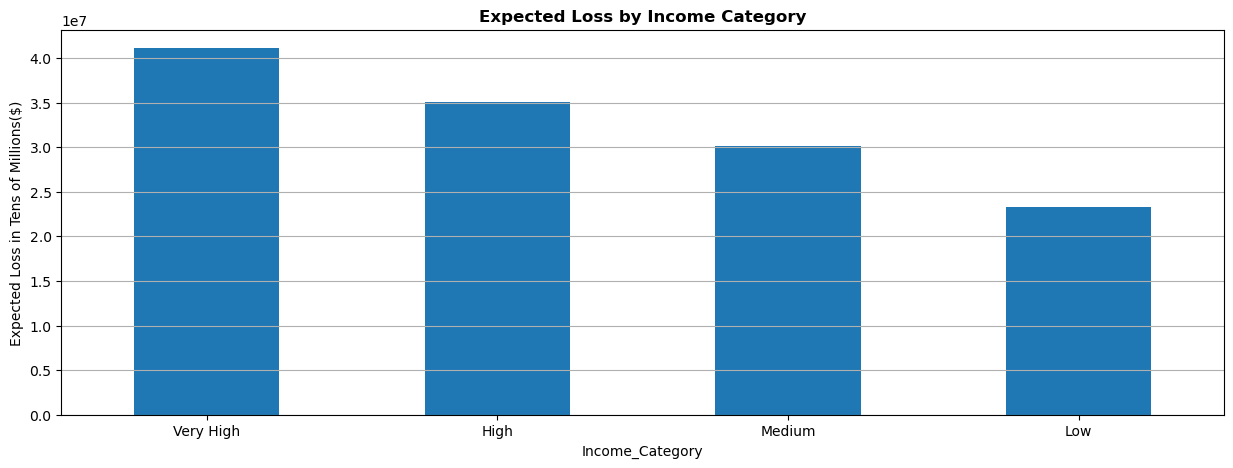

In [120]:
income_loss.plot( kind='bar', figsize=(15,5) )
plt.title('Expected Loss by Income Category',fontweight='bold') 
plt.ylabel('Expected Loss in Tens of Millions($)') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Very High income borrowers account for the largest total expected loss (~$41M), nearly double Low income's ~$23M, despite both groups being equal in borrower count (income segments are quartile-based).

- This is the same pattern seen in the age-income expected loss chart — dollar exposure trends toward higher-income borrowers, the opposite direction of default rate, which was highest among Low income borrowers.

- The gap between segments here is far less steep than the default-rate-by-income breakdown, where Low income defaulted at ~4x the rate of Very High — confirming again that default probability and dollar exposure tell different stories.

- Since Very High income carries the most total exposure but the lowest default rate, this segment represents lower-probability but larger-magnitude loss events — a different risk profile than Low income, which is higher-probability but smaller-magnitude.

## Which employment stability group has the highest Risk Score?

In [121]:
pd.reset_option('display.float_format')
employment_risk = df.groupby('Employment_Stability', observed=False)['Risk_Score'].mean().sort_values(ascending=False)
employment_risk

Employment_Stability
Low          0.406257
Medium       0.394416
High         0.383461
Very High    0.359302
Name: Risk_Score, dtype: float64

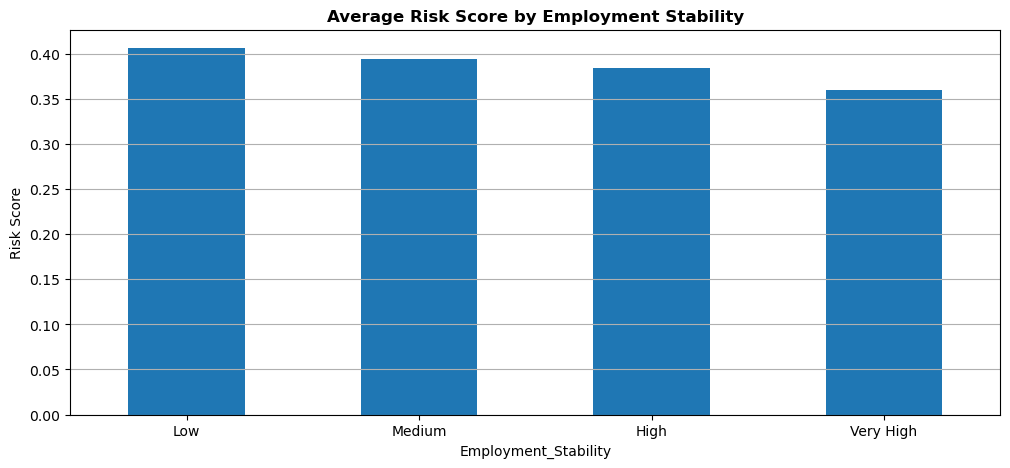

In [122]:
employment_risk.plot( kind='bar', figsize=(12,5) ) 
plt.title('Average Risk Score by Employment Stability',fontweight='bold') 
plt.ylabel('Risk Score') 
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

- Average Risk_Score decreases as employment stability increases, confirming Risk_Score is capturing at least some real signal from Employment_Stability, since this feeds directly into Financial_Health_Score (part of the score's formula

- The gap between Low and Very High stability is fairly narrow (~0.41 vs ~0.36), a much smaller spread than seen in the loan grade or default-rate breakdowns, suggesting employment stability alone is a weaker differentiator within the composite score.

- This pattern is directionally consistent with the earlier "Default Rate by Employment Stability" chart, where Low stability also had the highest actual default rate — meaning Risk_Score and real-world outcome agree on direction here, unlike the earlier age-income mismatch found with Risk_Score.

- The near-linear, evenly-spaced decline across all four tiers (no sharp jumps or flat segments) suggests employment stability contributes smoothly and predictably to the score, rather than only mattering at one extreme.

## What are the summary statistics of the portfolio Risk Score?

In [123]:
df['Risk_Score'].describe()

count    32409.000000
mean         0.392314
std          0.092301
min          0.134967
25%          0.326929
50%          0.387915
75%          0.453024
max          0.791450
Name: Risk_Score, dtype: float64

## Which borrowers combine low Financial Health and high Expected Loss?

In [124]:
critical = df[ (df['Financial_Health_Score'] <= df['Financial_Health_Score'].quantile(.25)) & (df['Expected_Loss'] >= df['Expected_Loss'].quantile(.90)) ] 
critical.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,Financial_Health_Score,Loan_Percent_Score,Interest_Score,Risk_Score,Risk_Segment,Expected_Loss,Exposure_Category,Young_High_Risk,Debt_Burden_Group,Risk_Zscore
12,23,95000,RENT,2.0,VENTURE,A,35000,7.90,1,0.37,...,0.036984,0.445783,0.139326,0.426647,High Risk,14932.635846,Critical,No,Critical,0.371973
16,23,120000,RENT,0.0,EDUCATION,A,35000,7.90,0,0.29,...,0.042776,0.349398,0.139326,0.386934,Medium Risk,13542.696296,Critical,No,Critical,-0.058285
31,25,120000,RENT,2.0,VENTURE,A,32000,6.62,0,0.27,...,0.043124,0.325301,0.067416,0.348462,Medium Risk,11150.780618,Critical,No,Critical,-0.475105
36,22,48000,RENT,1.0,EDUCATION,E,30000,18.39,1,0.63,...,0.018124,0.759036,0.728652,0.791450,Critical Risk,23743.511636,Critical,Yes,Critical,4.324365
49,26,89028,RENT,0.0,DEBTCONSOLIDATION,A,30000,6.62,1,0.34,...,0.028026,0.409639,0.067416,0.385216,Medium Risk,11556.494142,Critical,No,Critical,-0.076895
73,23,65000,RENT,2.0,EDUCATION,A,28000,7.90,1,0.43,...,0.029616,0.518072,0.139326,0.457036,Critical Risk,12797.008976,Critical,Yes,Critical,0.701220
74,26,85000,RENT,2.0,VENTURE,A,28000,7.49,1,0.33,...,0.041671,0.397590,0.116292,0.397219,High Risk,11122.126028,Critical,No,Critical,0.053142
79,24,83004,RENT,0.0,VENTURE,D,28000,15.99,1,0.34,...,0.033690,0.409639,0.593820,0.594646,Critical Risk,16650.076894,Critical,Yes,Critical,2.192123
87,24,69000,RENT,2.0,HOMEIMPROVEMENT,A,27600,10.99,1,0.40,...,0.030599,0.481928,0.312921,0.511820,Critical Risk,14126.229827,Critical,Yes,Critical,1.294765
93,24,73399,RENT,0.0,VENTURE,D,27000,10.99,1,0.37,...,0.024188,0.445783,0.312921,0.498644,Critical Risk,13463.395127,Critical,Yes,Critical,1.152016


- 7 of 10 borrowers hold Grade A loans, a striking result given this list was built specifically to find problem borrowers — meaning the lender's own grading system is missing a meaningful share of this risk profile entirely.

- Every borrower here rents, with no exceptions, making this the most uniform housing pattern seen across any high-risk cut in this project so far.

- Loan amounts are uniformly large (27,000-35,000), confirming this filter is correctly isolating the "high dollar exposure" side of Expected_Loss rather than the "high probability" side.

- 8 of 10 have already defaulted (loan_status = 1), despite most holding the supposedly safest Grade A — this is the clearest evidence yet in this project that loan grade alone is missing a real risk signal that Financial_Health_Score and Expected_Loss are picking up instead.

## How does Credit History Length affect Financial Health Score?

In [125]:
df[['cb_person_cred_hist_length','Financial_Health_Score']].corr()

,cb_person_cred_hist_length,Financial_Health_Score
cb_person_cred_hist_length,1.000000,0.724994
Financial_Health_Score,0.724994,1.000000


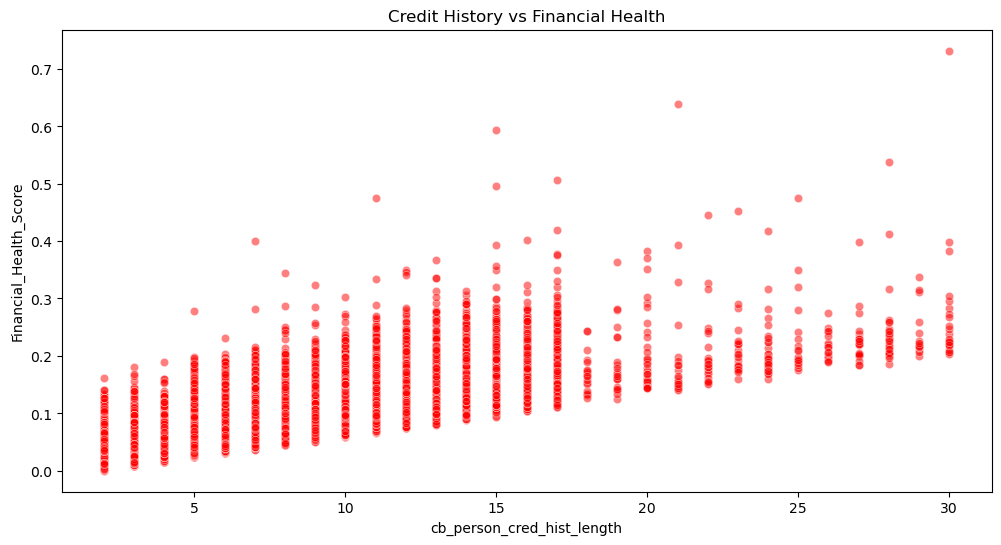

In [126]:
plt.figure(figsize=(12,6))
sns.scatterplot( data=df, x='cb_person_cred_hist_length', y='Financial_Health_Score',color='red', alpha=0.5 ) 
plt.title('Credit History vs Financial Health') 
plt.show()

- Credit history length correlates 0.72 with Financial_Health_Score, one of the strongest relationships found in this project, though this is expected given credit history is a direct input into the score's formula.

- The lower bound of Financial_Health_Score rises steadily with credit history length, forming a visible upward-sloping floor — borrowers with longer histories rarely score below roughly 0.1-0.15, while short-history borrowers can score near 0.

- Spread widens considerably as credit history increases, meaning longer history doesn't guarantee a high score — some 25-30 year borrowers still score as low as 0.2, similar to borrowers with only 5 years of history.

- The discrete vertical striping pattern reflects credit history being recorded in whole years, not a data quality issue — each column represents all borrowers sharing that exact year count.

## Which borrower profile represents the safest lending opportunity?

In [127]:
safe =  df.groupby( [ 'Age_Group', 'Income_Category', 'Employment_Stability' ],observed=False )['Risk_Score'] .mean() .sort_values() 
safe.head(10)

Age_Group  Income_Category  Employment_Stability
55+        Medium           High                    0.255095
46-55      Very High        Very High               0.300339
55+        Very High        High                    0.307571
           High             Very High               0.310830
           Very High        Very High               0.317072
36-45      Very High        Very High               0.321755
55+        Very High        Low                     0.322114
           High             High                    0.325673
46-55      Very High        High                    0.326963
55+        Very High        Medium                  0.331723
Name: Risk_Score, dtype: float64

- The single safest profile is (55+, Medium income, High employment stability), with an average Risk_Score of 0.255 — notably, Medium income outranks Very High income for the top spot, breaking the otherwise consistent "higher income = safer" pattern seen throughout this project.

- 55+ appears in 6 of the top 10 safest profiles, directly contradicting the earlier default-rate finding where 55+ had the highest actual default rate of any age group — this is the same Risk_Score/real-outcome mismatch flagged earlier in the age-income heatmap, now showing up again here.

- Very High income appears in 8 of the top 10 profiles, making income the most consistent factor across this safest-profile list, even though the very top spot is the Medium income exception.

- Employment_Stability is split fairly evenly between High and Very High across this list, suggesting once income and age are already favorable, employment stability differentiates safety only modestly rather than being a dominant factor — consistent with the earlier finding that Employment_Stability's spread in Risk_Score was comparatively narrow on its own.

## What are the key KPIs of the lending portfolio?

In [128]:
print(f"Total Borrowers: {len(df):,}") 
print(f"Default Rate: {df['loan_status'].mean()*100:.2f}%") 
print(f"Average Risk Score: {df['Risk_Score'].mean():.3f}") 
print(f"Average Financial Health Score: {df['Financial_Health_Score'].mean():.3f}") 
print(f"Total Portfolio Value: ${df['loan_amnt'].sum():,.0f}") 
print(f"Total Expected Loss: ${df['Expected_Loss'].sum():,.0f}") 
print(f"Average Loan Amount: ${df['loan_amnt'].mean():,.2f}")

Total Borrowers: 32,409
Default Rate: 21.87%
Average Risk Score: 0.392
Average Financial Health Score: 0.077
Total Portfolio Value: $310,882,900
Total Expected Loss: $129,630,365
Average Loan Amount: $9,592.49


# EXECUTIVE SUMMARY

I analyzed 32,409 borrower records (after cleaning) to understand the drivers of loan default, quantify portfolio risk, and build a custom risk-scoring framework to support lending decisions. The portfolio holds $310.88M in total loan value, with an overall default rate of 21.87% — notably high for a consumer lending book, and a strong signal that risk is not evenly distributed across the borrower base.

I built two constructed metrics to operationalize risk: a composite Risk_Score (weighted from loan-to-income burden, interest rate, and inverse financial health) and Expected_Loss (Risk_Score × loan amount). Both were validated against actual default outcomes and proved directionally sound — but the analysis surfaced a critical distinction that shapes every recommendation below: default probability and dollar exposure are driven by almost entirely different borrower characteristics, and treating them as the same thing would misallocate risk management resources.

# KEY FINDINGS

1. Income is the single strongest individual predictor of default.
Default rate falls from 39.7% (Low income) to 9.1% (Very High income) — a more than 4x spread, the widest gradient of any single categorical variable tested. Financial_Health_Score and Risk_Score both confirm this pattern independently.

2. Loan grade and interest rate are the most powerful validated risk signals.
Default rate rises from 9.96% (Grade A) to 98.4% (Grade G) — nearly a 10x spread. Interest rate shows a similar pattern, with Very High interest tier defaulting at 42.7% versus 9.6% for Low. Both align tightly with my constructed Risk_Score, which correlates 0.82 with interest rate and 0.46 with actual default — the strongest of any single component.

3. Debt burden and prior default history are strong secondary signals.
Borrowers with Critical debt burden default at 45.8%, nearly 4x the Low-burden group. Borrowers with a prior default on file default again at 37.9%, roughly double the rate of those with no prior default (18.4%).

4. Home ownership is a consistently strong, underused risk signal.
Renters default at 31.6%, versus just 7.5% for outright owners — a 4x gap that held up across nearly every cross-tabulation in this project. Renters also dominate every high-risk borrower list I pulled (top debt burden, top Risk_Score, statistical outliers).

5. Age shows a U-shaped default pattern that the current Risk_Score does not capture correctly.
Actual default rate is highest at both extremes of age (55+ at 23.9%, 18-25 at 23.1%), lowest in middle age (36-45 at 20.7%). However, my constructed Risk_Score ranks 18-25 as the highest-risk age group and 55+ relatively low — a direct disagreement with real outcomes. This is the single most important validity gap in the current scoring model.

6. Expected_Loss is driven almost entirely by loan amount, not by risk.
Expected_Loss correlates 0.95 with loan_amnt but only 0.46 with actual default status. The borrowers generating the highest dollar exposure (Very High income, ages 18-35) are not the same borrowers driving the highest default rates (Low income, ages 55+ and 18-25). Critical Risk segment alone accounts for 42.8% of total portfolio expected loss despite holding only 25% of borrowers by design (quartile split) — a genuine concentration, but one built on a metric dominated by loan size.

7. Loan grade significantly underprices a specific borrower profile.
A targeted filter for borrowers combining low Financial_Health_Score with high Expected_Loss found that 7 of 10 such borrowers held Grade A loans — the supposedly safest tier — and 8 of 10 had already defaulted. This indicates the current grading system is missing a real risk pattern that my constructed features are catching.

8. Loan purpose distinguishes default risk more than dollar exposure.
Debt Consolidation, Medical, and Home Improvement cluster at 26-29% default rate, while Venture sits lowest at 14.9% — yet Venture loans are comparably sized to the rest, and Education (not the highest-default category) generates the highest total Expected_Loss, purely on volume.

# RECOMMENDATIONS

1. Recalibrate Risk_Score's weighting using actual default outcomes, not fixed assumptions — run a logistic regression against loan_status to derive data-driven weights, specifically to fix the age mismatch identified above.
 
2. Incorporate home ownership status directly into the scoring model. It's currently absent from Risk_Score's formula despite being one of the most consistent standalone predictors found in this analysis.

3. Separate underwriting policy from portfolio exposure management. Grade/interest rate should continue driving loan pricing and approval (validated predictors), while Expected_Loss should inform capital reserve and concentration decisions — they answer different questions and neither should substitute for the other.

4. Flag the low-Financial_Health/high-Expected_Loss/Grade-A segment for manual underwriting review. This is the clearest evidence of a real gap between the current grading system and actual risk.

5. Treat "Critical Risk" and "Critical Exposure" segment labels carefully in stakeholder communication — both are relative quartile ranks, not absolute thresholds, and should always be presented alongside the validated default-rate-by-segment relationship (5% → 54% across segments) that gives them real meaning.